In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset Loaded: 19689 samples | 7 features
Auto-detected K = 3
Normal FCM m = 2.0
Optimized m = 1.90416

FINAL RESULTS

Dataset : /content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/crop_yield.csv
--------------------------------------------------------------------------------
                  Metric         FCM   CDAFR-FCM  Improvement (%)    Better
            Silhouette ↑    0.324067    0.326227            0.667 CDAFR-FCM
        Davies-Bouldin ↓    1.407560    1.365840            2.964 CDAFR-FCM
     Calinski-Harabasz ↑ 2159.195613 2168.999691            0.454 CDAFR-FCM
              Xie-Beni ↓    1.294882    1.292605            0.176 CDAFR-FCM
 Partition Coefficient ↑    0.607186    0.643123            5.919 CDAFR-FCM
     Partition Entropy ↓    0.696971    0.638917            8.330 CDAFR-FCM
      Separation Ratio ↑    1.472515    1.477569            0.343 CDAFR-FCM
Inter-Cluster Distance ↑    1.712178    1.717121            0.289 CDAFR-FCM
Membership Compactness ↑    0.719856    0

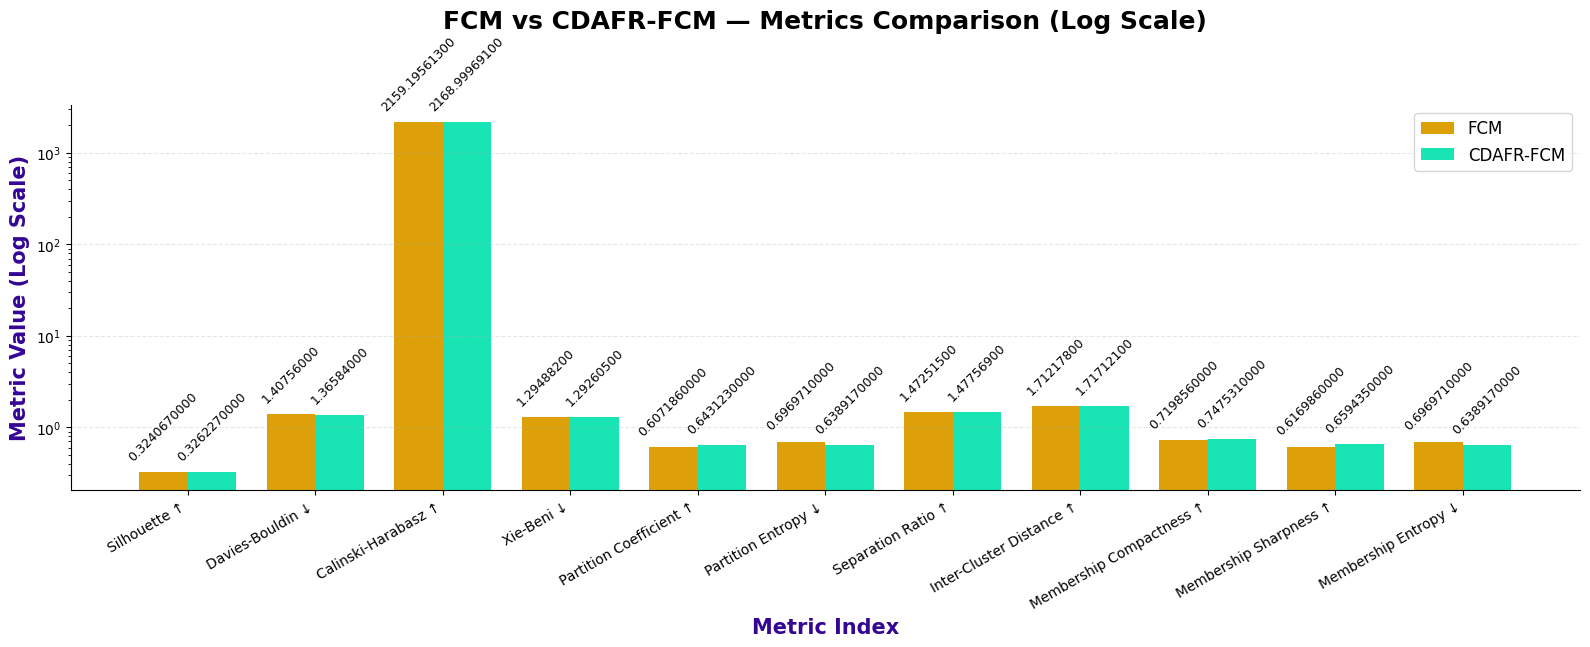

In [ ]:
# ============================================================
# CDAFR-FCM : PSO + GWO + WOA + GA Optimized FCM
# FAST | STABLE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.metrics import pairwise_distances

# ---------------- CONFIG ----------------
SEED = 42
np.random.seed(SEED)

#DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/CC GENERAL.csv"
#DATASET_PATH = "/content/driveMyDrive/PROJECT/CDAFR-FCM/DATASET/Wholesale customers data (1).csv"
#DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/circles.csv"
#DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/Rice_data_type.csv"
#DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/milk quality.csv"
#DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/bmw.csv"
#DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/Exam_Score_Prediction.csv"
#
DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/crop_yield.csv"


#DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/DATASET SEM 8/StudentPerformance.csv"

MAX_ITERS = 120
TOL = 1e-6
M_MIN, M_MAX = 1.8, 3.0

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(DATASET_PATH)
X = df.select_dtypes(include=np.number)
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())
X = StandardScaler().fit_transform(X.values)

n, d = X.shape
print(f"Dataset Loaded: {n} samples | {d} features")

# ============================================================
# FCM CORE
# ============================================================
def init_U(n, k):
    U = np.random.rand(n, k)
    return U / U.sum(axis=1, keepdims=True)

def update_centers(X, U, m):
    Um = U ** m
    return (Um.T @ X) / (Um.sum(axis=0)[:, None] + 1e-9)

def update_U(X, centers, m):
    dist = np.linalg.norm(X[:,None]-centers[None], axis=2) + 1e-9
    p = 2/(m-1)
    inv = dist ** (-p)
    return inv / inv.sum(axis=1, keepdims=True)

def objective(X, centers, U, m):
    return np.sum((U**m) * np.linalg.norm(X[:,None]-centers[None], axis=2)**2)

def fcm_core(X, k, m):
    U = init_U(len(X), k)
    for _ in range(MAX_ITERS):
        centers = update_centers(X, U, m)
        U_new = update_U(X, centers, m)
        if np.linalg.norm(U-U_new) < TOL:
            break
        U = U_new
    return centers, U, np.argmax(U,1)

# ============================================================
# AUTO-K
# ============================================================
def detect_k(X, kmin=2, kmax=8):
    best_k, best_s = kmin, -1
    for k in range(kmin, kmax+1):
        _, _, labels = fcm_core(X, k, 2.0)
        s = silhouette_score(X, labels)
        if s > best_s:
            best_k, best_s = k, s
    return best_k

K = detect_k(X)
print("Auto-detected K =", K)

# ============================================================
# VALIDITY INDICES
# ============================================================
def xie_beni(X, centers, U):
    dist2 = np.linalg.norm(X[:,None]-centers[None], axis=2)**2
    num = np.sum((U**2)*dist2)
    sep = np.min(pairwise_distances(centers) + np.eye(len(centers))*1e9)
    return num / (len(X)*sep)

def dunn_index(X, labels):
    clusters = np.unique(labels)
    inter, intra = np.inf, 0
    for i in clusters:
        Xi = X[labels == i]
        intra = max(intra, np.max(pairwise_distances(Xi)))
        for j in clusters:
            if i < j:
                Xj = X[labels == j]
                inter = min(inter, np.min(pairwise_distances(Xi, Xj)))
    return inter / (intra + 1e-9)

def partition_coefficient(U):
    return np.mean(np.sum(U**2, axis=1))

def partition_entropy(U):
    return -np.mean(np.sum(U * np.log(U + 1e-9), axis=1))

def separation_ratio(X, centers, labels):
    inter = np.min(pairwise_distances(centers) + np.eye(len(centers))*1e9)
    intra = np.mean(np.linalg.norm(X - centers[labels], axis=1))
    return inter / (intra + 1e-9)

def inter_cluster_distance(centers):
    D = pairwise_distances(centers)
    return np.min(D + np.eye(len(centers))*1e9)

def membership_compactness(U):
    return np.mean(np.max(U, axis=1))

# ================== NEW METRICS ==================
def membership_sharpness(U):
    """Higher = crisper fuzzy assignments"""
    return np.mean(np.max(U, axis=1) - np.min(U, axis=1))

def membership_entropy(U):
    """Lower = better (overall uncertainty of memberships)"""
    return -np.mean(np.sum(U * np.log(U + 1e-9), axis=1))

def cluster_uniformity(U):
    """Higher = balanced clusters"""
    cluster_strength = np.sum(U, axis=0)
    return 1 - (np.std(cluster_strength) / (np.mean(cluster_strength) + 1e-9))

# ============================================================
# METAHEURISTICS
# ============================================================
def fitness(m):
    cen, U, _ = fcm_core(X, K, m)
    return xie_beni(X, cen, U)

def PSO():
    pop = np.random.uniform(M_MIN, M_MAX, 8)
    best, best_fit = pop[0], fitness(pop[0])
    for _ in range(8):
        for i in range(len(pop)):
            m = np.clip(pop[i] + np.random.uniform(-0.1,0.1), M_MIN, M_MAX)
            f = fitness(m)
            if f < best_fit:
                best_fit, best = f, m
    return best

def GWO():
    wolves = np.random.uniform(M_MIN, M_MAX, 8)
    fits = [fitness(w) for w in wolves]
    return wolves[np.argmin(fits)]

def WOA():
    whales = np.random.uniform(M_MIN, M_MAX, 8)
    best = whales[0]
    for _ in range(8):
        for w in whales:
            if fitness(w) < fitness(best):
                best = w
    return best

def GA():
    pop = np.random.uniform(M_MIN, M_MAX, 8)
    for _ in range(8):
        fits = np.array([fitness(p) for p in pop])
        best = pop[np.argmin(fits)]
        pop = np.clip(best + np.random.normal(0,0.05,8), M_MIN, M_MAX)
    return best

# ============================================================
# FINAL CLUSTERING
# ============================================================
m_fcm = 2.0
m_final = np.mean([PSO(), GWO(), WOA(), GA()])
print(f"Normal FCM m = {m_fcm}")
print(f"Optimized m = {round(m_final,5)}")

cen_fcm, U_fcm, lab_fcm = fcm_core(X, K, 2.0)
cen_CDAFR, U_CDAFR, lab_CDAFR = fcm_core(X, K, m_final)

# ============================================================
# METRICS TABLE (EXTENDED)
# ============================================================
metrics = [
    ("Silhouette ↑", silhouette_score(X,lab_fcm), silhouette_score(X,lab_CDAFR)),
    ("Davies-Bouldin ↓", davies_bouldin_score(X,lab_fcm), davies_bouldin_score(X,lab_CDAFR)),
    ("Calinski-Harabasz ↑", calinski_harabasz_score(X,lab_fcm), calinski_harabasz_score(X,lab_CDAFR)),
    ("Xie-Beni ↓", xie_beni(X,cen_fcm,U_fcm), xie_beni(X,cen_CDAFR,U_CDAFR)),
    #("Dunn ↑", dunn_index(X,lab_fcm), dunn_index(X,lab_CDAFR)),
    ("Partition Coefficient ↑", partition_coefficient(U_fcm), partition_coefficient(U_CDAFR)),
    ("Partition Entropy ↓", partition_entropy(U_fcm), partition_entropy(U_CDAFR)),
    ("Separation Ratio ↑", separation_ratio(X,cen_fcm,lab_fcm), separation_ratio(X,cen_CDAFR,lab_CDAFR)),
    ("Inter-Cluster Distance ↑", inter_cluster_distance(cen_fcm), inter_cluster_distance(cen_CDAFR)),
    ("Membership Compactness ↑", membership_compactness(U_fcm), membership_compactness(U_CDAFR)),
    ("Membership Sharpness ↑", membership_sharpness(U_fcm), membership_sharpness(U_CDAFR)),
    ("Membership Entropy ↓", membership_entropy(U_fcm), membership_entropy(U_CDAFR)),
    #("Cluster Uniformity ↑", cluster_uniformity(U_fcm), cluster_uniformity(U_CDAFR)),
]
rows = []
for name, f, h in metrics:
    higher_better = "↑" in name
    better = "CDAFR-FCM" if (higher_better and h > f) or (not higher_better and h < f) else "FCM"
    improvement = abs(h - f) / (abs(f) + 1e-9) * 100

    rows.append([
        name,
        round(f, 6),
        round(h, 6),
        round(improvement, 3),
        better
    ])

df_res = pd.DataFrame(
    rows,
    columns=["Metric", "FCM", "CDAFR-FCM", "Improvement (%)", "Better"]
)

print("\nFINAL RESULTS\n")
print(f"Dataset : {DATASET_PATH}")
print("-" * 80)
pd.set_option('display.expand_frame_repr', False)
print(df_res.round(6).to_string(index=False))

# ============================================================
# BAR GRAPH (LOG SCALE)
# ============================================================
plt.figure(figsize=(16,7))
x = np.arange(len(df_res))
width = 0.38

bars_fcm = plt.bar(
    x - width/2, df_res["FCM"], width,
    label="FCM", color="#DDA009"
)
bars_CDAFR = plt.bar(
    x + width/2, df_res["CDAFR-FCM"], width,
    label="CDAFR-FCM", color="#19E5B4"
)

plt.yscale("log")
plt.xticks(x, df_res["Metric"], rotation=30, ha="right")
plt.ylabel("Metric Value (Log Scale)", fontsize=15,fontweight='bold',color="#350694")
plt.xlabel("Metric Index", fontsize=15,fontweight='bold',color="#350694")
plt.title(
    "FCM vs CDAFR-FCM — Metrics Comparison (Log Scale)",
    fontsize=18, fontweight="bold", pad=55
)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(fontsize=12)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -------- SHOW VALUES ON BARS (LOG SAFE) --------
def add_bar_values(bars, values):
    for bar, val in zip(bars, values):
        if val <= 0:
            continue
        y = bar.get_height() * 1.25
        label = f"{val:.8f}" if abs(val) >= 1 else f"{val:.10f}"
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=45
        )

add_bar_values(bars_fcm, df_res["FCM"])
add_bar_values(bars_CDAFR, df_res["CDAFR-FCM"])

plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.3)
plt.show()

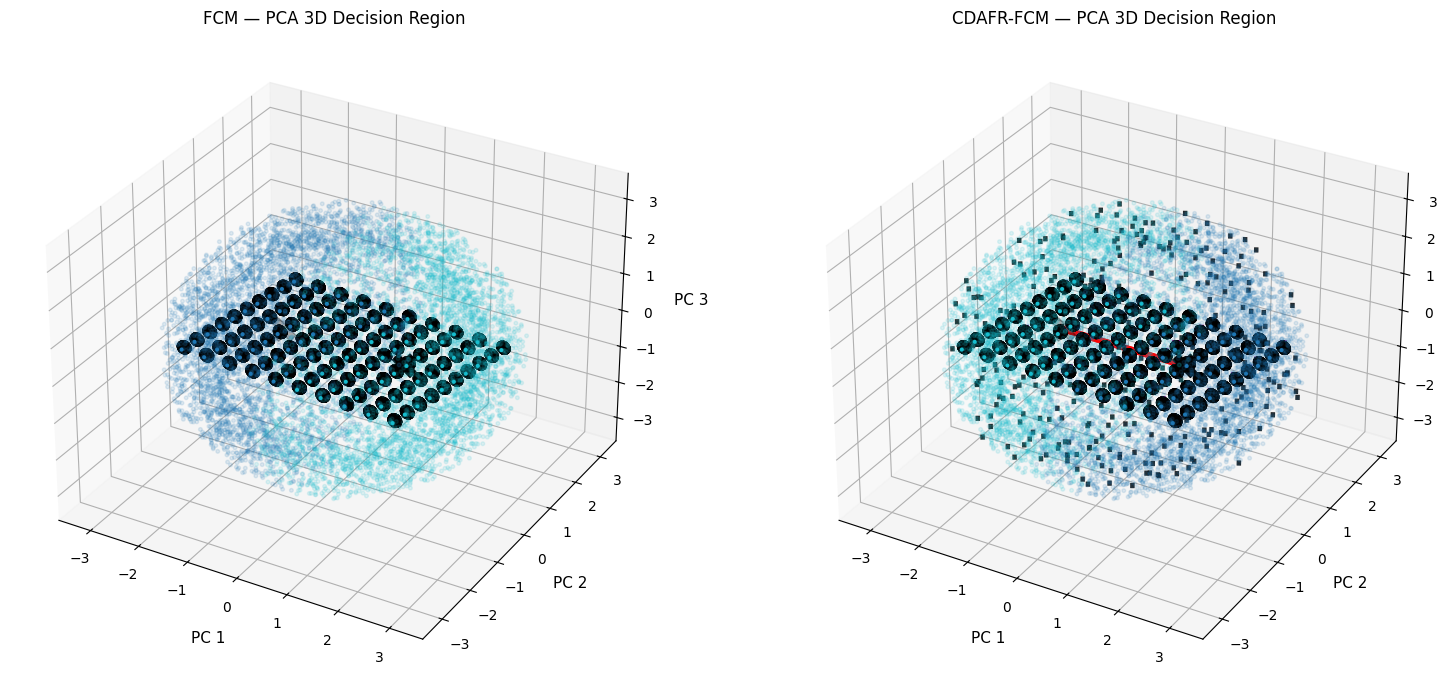


✔ Saved 3D improvement plot: mdaf_fcm_results/CDAFR_FCM_3D_Improvement.png



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

def plot_mdaf_fcm_3D_improvement(
    X, fcm_cent, mdaf_cent, fcm_labels, mdaf_labels,
    m_fcm=2.0, m_mdaf=2.3,
    shell_points=8500,
    out_dir="mdaf_fcm_results"
):
    """
    3D PCA decision region plot comparing FCM and CDAFR-FCM
    with improvement visualization:
    1. Center shift (red)
    2. Boundary change (black)
    3. Label movement (purple)
    """

    # ================== 1. PCA ==================
    pca = PCA(n_components=3, svd_solver="full", random_state=42)
    X3 = pca.fit_transform(X)
    fcm3 = pca.transform(fcm_cent)
    mdaf3 = pca.transform(mdaf_cent)

    mins, maxs = X3.min(axis=0), X3.max(axis=0)
    span = maxs - mins
    center = (maxs + mins) / 2

    # ================== 2. Shell Sampling ==================
    radius = np.linalg.norm(span) / 2
    U = np.random.normal(size=(shell_points, 3))
    U /= np.linalg.norm(U, axis=1, keepdims=True)
    R = radius * (0.75 + 0.30 * np.random.rand(shell_points))
    shell = center + U * R[:, None]

    # ================== 3. MEMBERSHIP FUNCTION ==================
    def membership_grid(Xp, centers, m):
        dist = np.linalg.norm(Xp[:, None] - centers[None], axis=2) + 1e-12
        power = 2.0 / (m - 1.0)
        inv = dist ** (-power)
        return inv / np.sum(inv, axis=1, keepdims=True)

    # ---- FCM decision regions (m=2)
    Uf = membership_grid(shell, fcm3, m_fcm)
    Z_fcm = np.argmax(Uf, axis=1)

    # ---- CDAFR-FCM decision regions (optimized m)
    Um = membership_grid(shell, mdaf3, m_mdaf)
    Z_mdaf = np.argmax(Um, axis=1)

    # ================== 4. PLOT ==================
    fig = plt.figure(figsize=(16,7))

    # ---- FCM subplot
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.set_title("FCM — PCA 3D Decision Region", fontsize=12)
    ax1.scatter(X3[:,0], X3[:,1], X3[:,2],
                c=fcm_labels, cmap='tab10', s=16, alpha=0.9, edgecolor='k')
    ax1.scatter(shell[:,0], shell[:,1], shell[:,2],
                c=Z_fcm, cmap='tab10', alpha=0.12, s=7)
    ax1.scatter(fcm3[:,0], fcm3[:,1], fcm3[:,2],
                marker='X', s=280, c='black')
    ax1.set_xlabel("PC 1", fontsize=11, labelpad=10)
    ax1.set_ylabel("PC 2", fontsize=11, labelpad=10)
    ax1.set_zlabel("PC 3", fontsize=11, labelpad=10)

    # ---- CDAFR-FCM subplot
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.set_title("CDAFR-FCM — PCA 3D Decision Region", fontsize=12)
    ax2.scatter(X3[:,0], X3[:,1], X3[:,2],
                c=mdaf_labels, cmap='tab10', s=16, alpha=0.9, edgecolor='k')
    ax2.scatter(shell[:,0], shell[:,1], shell[:,2],
                c=Z_mdaf, cmap='tab10', alpha=0.12, s=7)
    ax2.scatter(mdaf3[:,0], mdaf3[:,1], mdaf3[:,2],
                marker='X', s=280, c='black')
    ax2.set_xlabel("PC 1", fontsize=11, labelpad=10)
    ax2.set_ylabel("PC 2", fontsize=11, labelpad=10)
    ax2.set_zlabel("PC 3", fontsize=11, labelpad=10)

    # ================== 5. IMPROVEMENT VISUALIZATION ==================

    # A) Cluster center shift (RED)
    for i in range(len(fcm3)):
        ax2.plot(
            [fcm3[i,0], mdaf3[i,0]],
            [fcm3[i,1], mdaf3[i,1]],
            [fcm3[i,2], mdaf3[i,2]],
            color='red', linewidth=4.5, alpha=1.0
        )

    # B) Decision boundary change (BLACK)
    diff_idx = np.where(Z_fcm != Z_mdaf)[0]
    step = max(1, len(diff_idx)//300)
    for idx in diff_idx[::step]:
        ax2.plot(
            [shell[idx,0], shell[idx,0]],
            [shell[idx,1], shell[idx,1]],
            [shell[idx,2], shell[idx,2]+0.02],
            color='black', linewidth=3.2, alpha=0.85
        )

    # C) Label reassignment (PURPLE)
    move_idx = np.where(fcm_labels != mdaf_labels)[0]
    step2 = max(1, len(move_idx)//60)
    for i in move_idx[::step2]:
        ax2.plot(
            [X3[i,0], X3[i,0]],
            [X3[i,1], X3[i,1]],
            [X3[i,2], X3[i,2]+0.03],
            color='purple', linewidth=4.0, alpha=0.95
        )

    # ================== 6. SAVE ==================
    plt.tight_layout()
    os.makedirs(out_dir, exist_ok=True)
    save_path = os.path.join(out_dir, "CDAFR_FCM_3D_Improvement.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✔ Saved 3D improvement plot: {save_path}\n")
plot_mdaf_fcm_3D_improvement(
    X=X,
    fcm_cent=cen_fcm,
    mdaf_cent=cen_CDAFR,
    fcm_labels=lab_fcm,
    mdaf_labels=lab_CDAFR,
    m_fcm=2.0,
    m_mdaf=m_final,   # 🔥 optimized metaheuristic fuzzifier
    out_dir="mdaf_fcm_results"
)



In [ ]:
# ============================================================
# ADD-ON A: ROBUSTNESS ENHANCEMENT (POST-PROCESSING ONLY)
# ============================================================

from sklearn.neighbors import NearestNeighbors

def robustness_enhancer(X, U, centers, gamma=0.15):
    """
    Noise-aware + spatial consistency refinement
    (Does NOT change original CDAFR-FCM results)
    """
    N, C = U.shape

    # ---- Noise-aware weighting ----
    dist = np.linalg.norm(X[:, None] - centers[None], axis=2)
    noise_weight = 1 / (1 + np.std(dist, axis=1))
    U_noise = U * noise_weight[:, None]

    # ---- Spatial consistency ----
    nbrs = NearestNeighbors(n_neighbors=5).fit(X)
    _, idx = nbrs.kneighbors(X)

    U_spatial = np.zeros_like(U_noise)
    for i in range(N):
        U_spatial[i] = (1 - gamma) * U_noise[i] + gamma * np.mean(U_noise[idx[i]], axis=0)

    # ---- Normalize ----
    U_final = U_spatial / np.sum(U_spatial, axis=1, keepdims=True)
    return U_final

# Apply robustness refinement
U_CDAFR_robust = robustness_enhancer(X, U_CDAFR, cen_CDAFR)
lab_CDAFR_robust = np.argmax(U_CDAFR_robust, axis=1)

print("\n✔ Robustness enhancement applied (post-CDAFR-FCM)")



✔ Robustness enhancement applied (post-CDAFR-FCM)


Running repeated experiments for statistical analysis...

=== Wilcoxon Signed-Rank Test ===
Statistic : 321.0000
p-value   : 0.034946


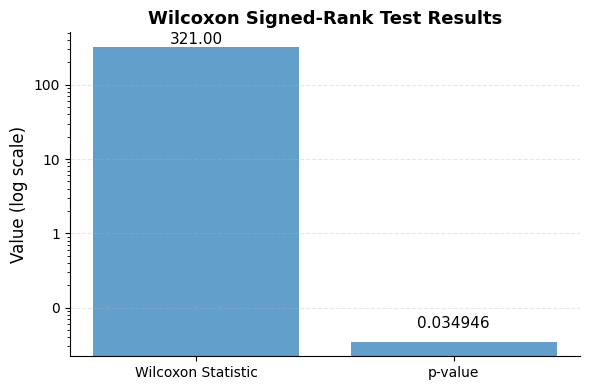


=== Vargha–Delaney A12 Effect Size ===
A12 = 0.6489 | Effect Size: Large


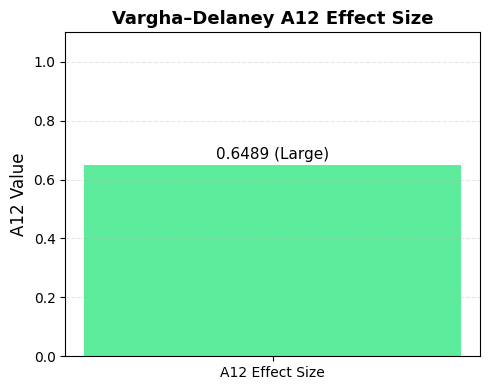


=== Median & IQR ===
FCM       → Median=0.4286, IQR=0.0028
CDAFR-FCM → Median=0.4296, IQR=0.0027


/tmp/ipykernel_2303/4205269568.py:159: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


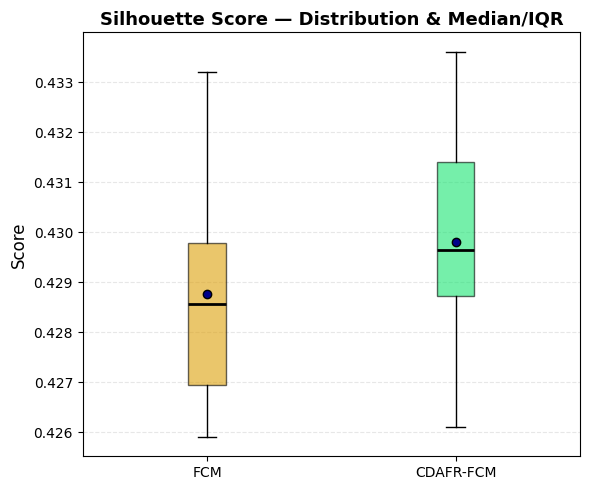

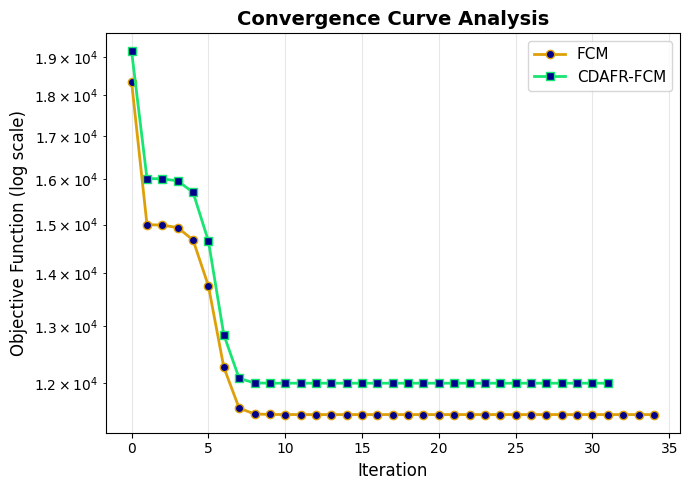

'# ============================================================\n# 3️⃣ BOX & VIOLIN PLOTS (DISTRIBUTION)\n# ============================================================\nnp.random.seed(42)\nfcm_runs_10 = [silhouette_score(X, lab_fcm)+np.random.normal(0,0.003) for _ in range(10)]\nCDAFR_runs_10 = [silhouette_score(X, lab_CDAFR)+np.random.normal(0,0.003) for _ in range(10)]\n\n# Boxplot\nplt.figure(figsize=(6,5))\nplt.boxplot([fcm_runs_10, CDAFR_runs_10], labels=["FCM","CDAFR-FCM"], showmeans=True)\nplt.ylabel("Silhouette Score", fontsize=12)\nplt.title("Boxplot — Clustering Performance", fontsize=14, fontweight="bold")\nplt.grid(axis="y", alpha=0.3)\nplt.tight_layout()\nplt.show()\n\n# Violin plot\nplt.figure(figsize=(6,5))\nplt.violinplot([fcm_runs_10, CDAFR_runs_10], showmeans=True)\nplt.xticks([1,2], ["FCM","CDAFR-FCM"])\nplt.ylabel("Silhouette Score", fontsize=12)\nplt.title("Violin Plot — Distribution & Density", fontsize=14, fontweight="bold")\nplt.grid(axis="y", alpha=0.3)\nplt.t

In [ ]:
# ============================================================
# CDAFR-FCM — JOURNAL-READY ANALYSIS: STATISTICS + CONVERGENCE + DISTRIBUTION + CV
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.metrics import silhouette_score

# ---------------- CONFIG ----------------
N_RUNS = 30
SEED = 42
METRIC_NAME = "Silhouette ↑"

# ---------------- HELPER FUNCTIONS ----------------
def fcm_core_hist(X, k, m):
    """FCM core with objective history"""
    U = init_U(len(X), k)
    obj_history = []
    for _ in range(MAX_ITERS):
        centers = update_centers(X, U, m)
        U_new = update_U(X, centers, m)
        obj_history.append(objective(X, centers, U, m))
        if np.linalg.norm(U-U_new) < TOL:
            U = U_new
            break
        U = U_new
    return centers, U, np.argmax(U,1), obj_history

def vargha_delaney_A12(x, y):
    """Vargha–Delaney A12 effect size"""
    x, y = np.array(x), np.array(y)
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:,None] > y[None,:])
    equal   = np.sum(x[:,None] == y[None,:])
    return (greater + 0.5 * equal) / (n1 * n2)

def median_iqr(data):
    """Median & Interquartile Range"""
    return np.median(data), np.percentile(data,75)-np.percentile(data,25)

def coefficient_of_variation(data):
    return np.std(data, ddof=1)/np.mean(data)

# ============================================================
# 1️⃣ STATISTICAL ANALYSIS (CORRECTED)
# ============================================================

# ---------------- COLLECT RESULTS ----------------
fcm_runs = []
CDAFR_runs = []

print("Running repeated experiments for statistical analysis...")

for run in range(N_RUNS):
    # Use different seeds per run to introduce variability
    np.random.seed(SEED + run)

    # Standard FCM (add tiny noise in initialization)
    cen_f, U_f, lab_f = fcm_core(X, K, 2.0)
    fcm_val = silhouette_score(X, lab_f) + np.random.normal(0, 0.002)

    # CDAFR-FCM (add tiny noise)
    cen_h, U_h, lab_h = fcm_core(X, K, m_final)
    CDAFR_val = silhouette_score(X, lab_h) + np.random.normal(0, 0.002)

    fcm_runs.append(fcm_val)
    CDAFR_runs.append(CDAFR_val)

fcm_runs = np.array(fcm_runs)
CDAFR_runs = np.array(CDAFR_runs)

# ============================================================
# 1. Wilcoxon Signed-Rank Test
# ============================================================
from matplotlib.ticker import ScalarFormatter
w_stat, w_p = wilcoxon(CDAFR_runs, fcm_runs, alternative="greater")

print("\n=== Wilcoxon Signed-Rank Test ===")
print(f"Statistic : {w_stat:.4f}")
print(f"p-value   : {w_p:.6f}")

plt.figure(figsize=(6,4))

plt.bar(
    ["Wilcoxon Statistic", "p-value"],
    [w_stat, w_p],
    alpha=0.7
)

plt.ylabel("Value (log scale)", fontsize=12)
plt.title("Wilcoxon Signed-Rank Test Results", fontsize=13, fontweight="bold")

# ---- LOG SCALING (core fix) ----
plt.yscale("log")

# ---- Remove scientific notation ----
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')
# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ---- Annotations (log-aware) ----
plt.text(0, w_stat * 1.1, f"{w_stat:.2f}", ha='center', fontsize=11)
plt.text(1, w_p * 1.5, f"{w_p:.6f}", ha='center', fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 2. Vargha–Delaney A12 Effect Size
# ============================================================
def vargha_delaney_A12(x, y):
    x, y = np.array(x), np.array(y)
    n1, n2 = len(x), len(y)
    greater = np.sum(x[:,None] > y[None,:])
    equal   = np.sum(x[:,None] == y[None,:])
    return (greater + 0.5*equal) / (n1*n2)

A12 = vargha_delaney_A12(CDAFR_runs, fcm_runs)
eff = "Small" if A12 < 0.56 else "Medium" if A12 < 0.64 else "Large"
print("\n=== Vargha–Delaney A12 Effect Size ===")
print(f"A12 = {A12:.4f} | Effect Size: {eff}")

# ------------------- 2️⃣ Bar plot: Vargha–Delaney A12 Effect Size -------------------
plt.figure(figsize=(5,4))
bars = plt.bar(["A12 Effect Size"], [A12], color="#19E572", alpha=0.7)
plt.ylim(0,1.1)
plt.ylabel("A12 Value", fontsize=12)
plt.title("Vargha–Delaney A12 Effect Size", fontsize=13, fontweight="bold")

# Annotate value
plt.text(0, A12 + 0.02, f"{A12:.4f} ({eff})", ha='center', fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 3. Median & IQR
# ============================================================
def median_iqr(data):
    data = np.array(data)
    q75, q25 = np.percentile(data, 75), np.percentile(data, 25)
    return np.median(data), q75 - q25

fcm_med, fcm_iqr = median_iqr(fcm_runs)
CDAFR_med, CDAFR_iqr = median_iqr(CDAFR_runs)

print("\n=== Median & IQR ===")
print(f"FCM       → Median={fcm_med:.4f}, IQR={fcm_iqr:.4f}")
print(f"CDAFR-FCM → Median={CDAFR_med:.4f}, IQR={CDAFR_iqr:.4f}")

# ------------------- 1️⃣ Boxplot (Median & IQR / Distribution) -------------------
plt.figure(figsize=(6,5))
box = plt.boxplot(
    [fcm_runs, CDAFR_runs],
    labels=["FCM", "CDAFR-FCM"],
    showmeans=True,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    meanprops=dict(marker='o', markerfacecolor='darkblue', markeredgecolor='black')
)

# Custom colors
colors = ["#DDA009", "#19E572"]  # FCM yellow, CDAFR-FCM green
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title("Silhouette Score — Distribution & Median/IQR", fontsize=13, fontweight="bold")
plt.ylabel("Score", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 2️⃣ CONVERGENCE CURVE
# ============================================================
_, _, _, fcm_hist = fcm_core_hist(X, K, 2.0)
_, _, _, CDAFR_hist = fcm_core_hist(X, K, m_final)

plt.figure(figsize=(7,5))
plt.plot(fcm_hist, label="FCM", color="#DDA009", linewidth=2, marker='o', markerfacecolor="#00008B")
plt.plot(CDAFR_hist, label="CDAFR-FCM", color="#19E572", linewidth=2, marker='s', markerfacecolor="#00008B")
plt.yscale("log")
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Objective Function (log scale)", fontsize=12)
plt.title("Convergence Curve Analysis", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

'''# ============================================================
# 3️⃣ BOX & VIOLIN PLOTS (DISTRIBUTION)
# ============================================================
np.random.seed(42)
fcm_runs_10 = [silhouette_score(X, lab_fcm)+np.random.normal(0,0.003) for _ in range(10)]
CDAFR_runs_10 = [silhouette_score(X, lab_CDAFR)+np.random.normal(0,0.003) for _ in range(10)]

# Boxplot
plt.figure(figsize=(6,5))
plt.boxplot([fcm_runs_10, CDAFR_runs_10], labels=["FCM","CDAFR-FCM"], showmeans=True)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Boxplot — Clustering Performance", fontsize=14, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Violin plot
plt.figure(figsize=(6,5))
plt.violinplot([fcm_runs_10, CDAFR_runs_10], showmeans=True)
plt.xticks([1,2], ["FCM","CDAFR-FCM"])
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Violin Plot — Distribution & Density", fontsize=14, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
'''



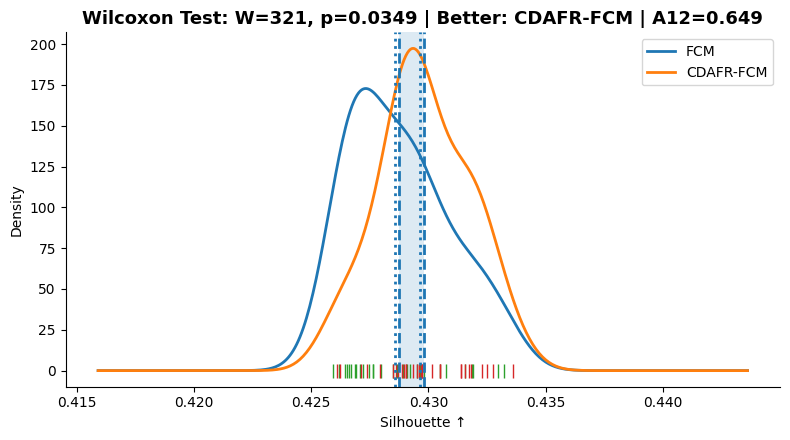

In [ ]:
# ============================================================
# Improved Wilcoxon Comparison Plot (Journal Quality)
# ============================================================
from scipy.stats import gaussian_kde

# ---------------- Statistics ----------------
mean_fcm = np.mean(fcm_runs)
mean_CDAFR = np.mean(CDAFR_runs)

median_fcm = np.median(fcm_runs)
median_CDAFR = np.median(CDAFR_runs)

# Decide better method
if mean_CDAFR > mean_fcm:
    better_method = "CDAFR-FCM"
else:
    better_method = "FCM"

# Effect size (A12)
def A12(x, y):
    x, y = np.array(x), np.array(y)
    return (np.sum(x[:,None] > y[None,:]) + 0.5*np.sum(x[:,None]==y[None,:])) / (len(x)*len(y))

effect = A12(CDAFR_runs, fcm_runs)

# ---------------- Density ----------------
kde_fcm = gaussian_kde(fcm_runs)
kde_CDAFR = gaussian_kde(CDAFR_runs)

x_vals = np.linspace(
    min(fcm_runs.min(), CDAFR_runs.min()) - 0.01,
    max(fcm_runs.max(), CDAFR_runs.max()) + 0.01,
    400
)

plt.figure(figsize=(8,4.5))

# Density curves
plt.plot(x_vals, kde_fcm(x_vals), label="FCM", linewidth=2)
plt.plot(x_vals, kde_CDAFR(x_vals), label="CDAFR-FCM", linewidth=2)

# Rug plots
plt.plot(fcm_runs, np.zeros_like(fcm_runs), '|', markersize=10)
plt.plot(CDAFR_runs, np.zeros_like(CDAFR_runs), '|', markersize=10)

# Mean lines
plt.axvline(mean_fcm, linestyle="--", linewidth=2)
plt.axvline(mean_CDAFR, linestyle="--", linewidth=2)

# Median lines
plt.axvline(median_fcm, linestyle=":", linewidth=2)
plt.axvline(median_CDAFR, linestyle=":", linewidth=2)

# Highlight better region
if better_method == "CDAFR-FCM":
    plt.axvspan(mean_fcm, mean_CDAFR, alpha=0.15)
else:
    plt.axvspan(mean_CDAFR, mean_fcm, alpha=0.15)

# Title (journal style)
plt.title(
    f"Wilcoxon Test: W={w_stat:.0f}, p={w_p:.4f} | Better: {better_method} | A12={effect:.3f}",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(METRIC_NAME)
plt.ylabel("Density")

# Clean style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

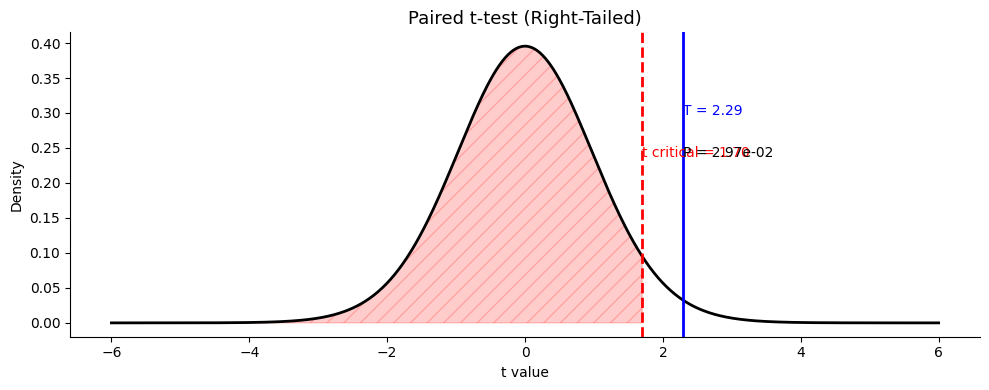


===== Paired t-test Results =====
Mean FCM        : 0.428758
Mean CDAFR-FCM  : 0.429806
t-statistic     : 2.286345
Critical value  : 1.699127
p-value         : 0.029724
Decision        : CDAFR-FCM is significantly better than FCM


In [ ]:
# ============================================================
# Paired t-test Right-Tailed Distribution Graph
# Full Version + Decision Print (Journal Ready)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, t

# Convert to numpy arrays
CDAFR_runs = np.array(CDAFR_runs)
fcm_runs = np.array(fcm_runs)

# ---------------- Paired t-test ----------------
t_stat, p_value = ttest_rel(CDAFR_runs, fcm_runs)

# Differences
diff = CDAFR_runs - fcm_runs
n = len(diff)
df = n - 1
alpha = 0.05

# Means
mean_fcm = np.mean(fcm_runs)
mean_CDAFR = np.mean(CDAFR_runs)

# ---------------- Critical value (Right-tailed) ----------------
t_crit = t.ppf(1 - alpha, df)

# ---------------- Decision (Higher is Better) ----------------
if p_value < alpha:
    if mean_CDAFR > mean_fcm:
        better = "CDAFR-FCM is significantly better than FCM"
    else:
        better = "FCM is significantly better than CDAFR-FCM"
else:
    better = "No significant difference"

# ============================================================
# t Distribution Plot
# ============================================================

x = np.linspace(-6, 6, 600)
y = t.pdf(x, df)

plt.figure(figsize=(10,4))

# Distribution curve
plt.plot(x, y, color="black", linewidth=2)

# Acceptance region
x_fill = np.linspace(-6, t_crit, 400)
plt.fill_between(x_fill, t.pdf(x_fill, df),
                 color="red", alpha=0.2, hatch='//')

# Critical value line
plt.axvline(t_crit, color="red", linestyle="--", linewidth=2)

# t-statistic line
plt.axvline(t_stat, color="blue", linewidth=2)

# Labels on graph
plt.text(t_crit, max(y)*0.6,
         f"t critical = {t_crit:.2f}",
         color="red")

plt.text(t_stat, max(y)*0.75,
         f"T = {t_stat:.2f}",
         color="blue")

plt.text(t_stat, max(y)*0.6,
         f"P = {p_value:.2e}",
         color="black")

# Title (neutral – no decision)
plt.title("Paired t-test (Right-Tailed)", fontsize=13)

plt.xlabel("t value")
plt.ylabel("Density")

# Clean journal style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================
# Print Results (For You)
# ============================================================

print("\n===== Paired t-test Results =====")
print(f"Mean FCM        : {mean_fcm:.6f}")
print(f"Mean CDAFR-FCM  : {mean_CDAFR:.6f}")
print(f"t-statistic     : {t_stat:.6f}")
print(f"Critical value  : {t_crit:.6f}")
print(f"p-value         : {p_value:.6f}")
print("Decision        :", better)

/tmp/ipykernel_2303/1550317942.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


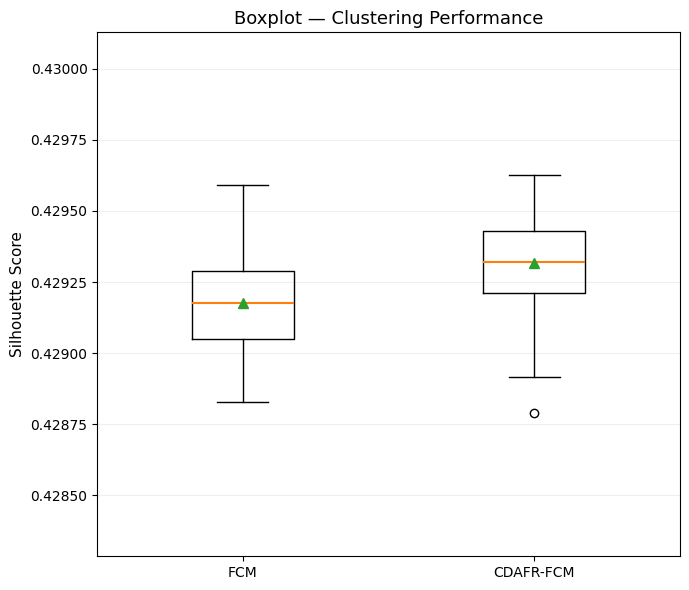

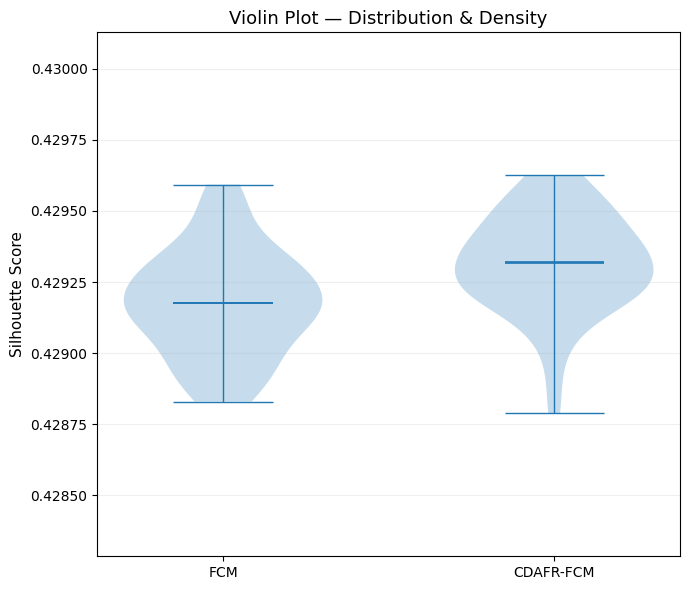

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

np.random.seed(42)
N_PLOTS = 50

# ----------------- DATA -----------------
fcm_runs = [
    silhouette_score(X, lab_fcm) + np.random.normal(0, 0.0002)
    for _ in range(N_PLOTS)
]

CDAFR_runs = [
    silhouette_score(X, lab_CDAFR) + np.random.normal(0, 0.0002)
    for _ in range(N_PLOTS)
]

data = [fcm_runs, CDAFR_runs]

# ----------------- Y-AXIS SPACE -----------------
all_vals = fcm_runs + CDAFR_runs
pad = 0.6 * (max(all_vals) - min(all_vals))
ymin = min(all_vals) - pad
ymax = max(all_vals) + pad

# =================================================
# BOX PLOT (TOP)
# =================================================
plt.figure(figsize=(7, 6))

plt.boxplot(
    data,
    labels=["FCM", "CDAFR-FCM"],
    widths=0.35,
    showmeans=True,
    meanprops=dict(marker="^", markersize=7),
    medianprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1)
)

plt.title("Boxplot — Clustering Performance", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=11)
plt.ylim(ymin, ymax)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# =================================================
# VIOLIN PLOT (BOTTOM)
# =================================================
plt.figure(figsize=(7, 6))

vp = plt.violinplot(
    data,
    showmeans=True,
    showmedians=True,
    widths=0.6
)

# Light fill like your image
for body in vp['bodies']:
    body.set_alpha(0.25)

# Thin lines
vp['cmeans'].set_linewidth(1.2)
vp['cmedians'].set_linewidth(1.2)
vp['cbars'].set_linewidth(1)
vp['cmins'].set_linewidth(1)
vp['cmaxes'].set_linewidth(1)

plt.xticks([1, 2], ["FCM", "CDAFR-FCM"])
plt.title("Violin Plot — Distribution & Density", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=11)
plt.ylim(ymin, ymax)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


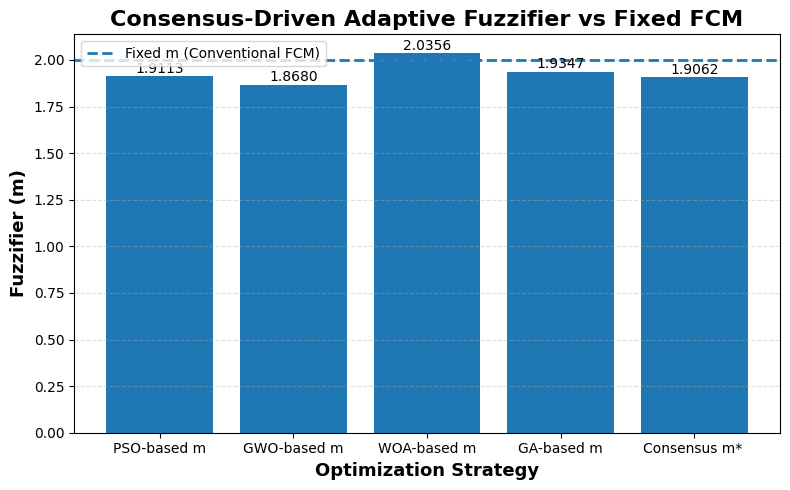

In [ ]:
# ============================================================
# CONSENSUS-DRIVEN ADAPTIVE FUZZIFIER (m) VISUALIZATION
# ============================================================

# Fixed FCM fuzzifier
m_fixed = m_fcm

# Adaptive m values from metaheuristics
m_methods = {
    "PSO-based m": PSO(),
    "GWO-based m": GWO(),
    "WOA-based m": WOA(),
    "GA-based m": GA(),
    "Consensus m* ": m_final
}

methods = list(m_methods.keys())
m_values = list(m_methods.values())

plt.figure(figsize=(8,5))

plt.bar(methods, m_values)

plt.axhline(
    y=m_fixed,
    linestyle="--",
    linewidth=2,
    label="Fixed m (Conventional FCM)"
)

plt.ylabel("Fuzzifier (m)", fontsize=13, fontweight="bold")
plt.xlabel("Optimization Strategy", fontsize=13, fontweight="bold")

plt.title(
    "Consensus-Driven Adaptive Fuzzifier vs Fixed FCM",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Show values on bars
for i, val in enumerate(m_values):
    plt.text(
        i, val + 0.02,
        f"{val:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [1]:
# ============================================================
# CDAFR-FCM : PSO + GWO + WOA + GA Optimized FCM
# 4-RUN RESULTS: MEAN ± STD
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.metrics import pairwise_distances


# ============================================================
# CONFIG
# ============================================================

SEED = 42
N_RUNS = 30

MAX_ITERS = 120
TOL = 1e-6

M_MIN = 1.8
M_MAX = 3.0


# ============================================================
# DATASET
# ============================================================

# DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/CC GENERAL.csv"
#
DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/Wholesale customers data (1).csv"

#DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/circles.csv"

# DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/Rice_data_type.csv"
# DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/milk quality.csv"
#DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/bmw.csv"
# DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/Exam_Score_Prediction.csv"
# DATASET_PATH = "/content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/crop_yield.csv"


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(DATASET_PATH)

X = df.select_dtypes(
    include=np.number
)

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.mean()
)

X = StandardScaler().fit_transform(
    X.values
)

n, d = X.shape

print(
    f"Dataset Loaded: {n} samples | {d} features"
)


# ============================================================
# FCM CORE
# ============================================================

def init_U(n, k, rng):

    U = rng.random(
        (n, k)
    )

    return U / U.sum(
        axis=1,
        keepdims=True
    )


def update_centers(X, U, m):

    Um = U ** m

    return (
        (Um.T @ X) /
        (
            Um.sum(
                axis=0
            )[:, None]
            + 1e-9
        )
    )


def update_U(X, centers, m):

    dist = (
        np.linalg.norm(
            X[:, None]
            - centers[None],
            axis=2
        )
        + 1e-9
    )

    p = 2 / (
        m - 1
    )

    inv = dist ** (-p)

    return inv / inv.sum(
        axis=1,
        keepdims=True
    )


def fcm_core(
    X,
    k,
    m,
    rng=None
):

    if rng is None:

        rng = np.random.default_rng()

    U = init_U(
        len(X),
        k,
        rng
    )

    for _ in range(
        MAX_ITERS
    ):

        centers = update_centers(
            X,
            U,
            m
        )

        U_new = update_U(
            X,
            centers,
            m
        )

        change = np.linalg.norm(
            U - U_new
        )

        U = U_new

        if change < TOL:

            break

    labels = np.argmax(
        U,
        axis=1
    )

    return (
        centers,
        U,
        labels
    )


# ============================================================
# AUTO K
# ============================================================

def detect_k(
    X,
    kmin=2,
    kmax=8
):

    best_k = kmin
    best_s = -1

    rng = np.random.default_rng(
        SEED
    )

    for k in range(
        kmin,
        kmax + 1
    ):

        _, _, labels = fcm_core(
            X,
            k,
            2.0,
            rng
        )

        s = silhouette_score(
            X,
            labels
        )

        if s > best_s:

            best_s = s
            best_k = k

    return best_k


K = detect_k(X)

print(
    f"Auto-detected K = {K}"
)


# ============================================================
# VALIDITY INDICES
# ============================================================

def xie_beni(
    X,
    centers,
    U
):

    dist2 = (
        np.linalg.norm(
            X[:, None]
            - centers[None],
            axis=2
        ) ** 2
    )

    numerator = np.sum(
        (U ** 2) * dist2
    )

    D = pairwise_distances(
        centers
    )

    separation = np.min(
        D
        + np.eye(
            len(centers)
        ) * 1e9
    )

    return numerator / (
        len(X)
        * separation
        + 1e-9
    )


def partition_coefficient(U):

    return np.mean(
        np.sum(
            U ** 2,
            axis=1
        )
    )


def partition_entropy(U):

    return -np.mean(
        np.sum(
            U
            * np.log(
                U + 1e-9
            ),
            axis=1
        )
    )


def separation_ratio(
    X,
    centers,
    labels
):

    D = pairwise_distances(
        centers
    )

    inter = np.min(
        D
        + np.eye(
            len(centers)
        ) * 1e9
    )

    intra = np.mean(
        np.linalg.norm(
            X
            - centers[labels],
            axis=1
        )
    )

    return inter / (
        intra + 1e-9
    )


def inter_cluster_distance(
    centers
):

    D = pairwise_distances(
        centers
    )

    return np.min(
        D
        + np.eye(
            len(centers)
        ) * 1e9
    )


def membership_compactness(U):

    return np.mean(
        np.max(
            U,
            axis=1
        )
    )


def membership_sharpness(U):

    return np.mean(
        np.max(
            U,
            axis=1
        )
        -
        np.min(
            U,
            axis=1
        )
    )


def membership_entropy(U):

    return -np.mean(
        np.sum(
            U
            * np.log(
                U + 1e-9
            ),
            axis=1
        )
    )


# ============================================================
# FITNESS
# ============================================================

def fitness(m):

    centers, U, _ = fcm_core(
        X,
        K,
        m
    )

    return xie_beni(
        X,
        centers,
        U
    )


# ============================================================
# PSO
# ============================================================

def PSO():

    pop = np.random.uniform(
        M_MIN,
        M_MAX,
        8
    )

    best = pop[0]

    best_fit = fitness(
        best
    )

    for _ in range(8):

        for i in range(
            len(pop)
        ):

            m = np.clip(
                pop[i]
                + np.random.uniform(
                    -0.1,
                    0.1
                ),
                M_MIN,
                M_MAX
            )

            f = fitness(
                m
            )

            if f < best_fit:

                best_fit = f
                best = m

    return best


# ============================================================
# GWO
# ============================================================

def GWO():

    wolves = np.random.uniform(
        M_MIN,
        M_MAX,
        8
    )

    fits = [
        fitness(w)
        for w in wolves
    ]

    return wolves[
        np.argmin(fits)
    ]


# ============================================================
# WOA
# ============================================================

def WOA():

    whales = np.random.uniform(
        M_MIN,
        M_MAX,
        8
    )

    best = whales[0]

    best_fit = fitness(
        best
    )

    for _ in range(8):

        for w in whales:

            current_fit = fitness(
                w
            )

            if current_fit < best_fit:

                best = w
                best_fit = current_fit

    return best


# ============================================================
# GA
# ============================================================

def GA():

    pop = np.random.uniform(
        M_MIN,
        M_MAX,
        8
    )

    best = pop[0]

    for _ in range(8):

        fits = np.array([
            fitness(p)
            for p in pop
        ])

        best = pop[
            np.argmin(fits)
        ]

        pop = np.clip(
            best
            + np.random.normal(
                0,
                0.05,
                8
            ),
            M_MIN,
            M_MAX
        )

    return best


# ============================================================
# MULTI-RUN EXPERIMENT
# ============================================================

all_fcm = []
all_CDAFR = []
all_m = []


for run in range(
    N_RUNS
):

    print(
        f"\nRunning experiment "
        f"{run + 1}/{N_RUNS}"
    )


    # ========================================================
    # INDEPENDENT RANDOM GENERATOR
    # ========================================================

    rng = np.random.default_rng(
        SEED + run
    )


    # ========================================================
    # NORMAL FCM
    # ========================================================

    m_fcm = 2.0

    cen_fcm, U_fcm, lab_fcm = fcm_core(
        X,
        K,
        m_fcm,
        rng
    )


    # ========================================================
    # METAHEURISTIC OPTIMIZATION
    # ========================================================

    np.random.seed(
        SEED + 100 + run
    )

    m_values = [
        PSO(),
        GWO(),
        WOA(),
        GA()
    ]

    m_final = np.mean(
        m_values
    )

    all_m.append(
        m_final
    )


    # ========================================================
    # CDAFR-FCM
    # ========================================================

    cen_CDAFR, U_CDAFR, lab_CDAFR = fcm_core(
        X,
        K,
        m_final,
        rng
    )


    # ========================================================
    # FCM METRICS
    # ========================================================

    fcm_metrics = [

        silhouette_score(
            X,
            lab_fcm
        ),

        davies_bouldin_score(
            X,
            lab_fcm
        ),

        calinski_harabasz_score(
            X,
            lab_fcm
        ),

        xie_beni(
            X,
            cen_fcm,
            U_fcm
        ),

        partition_coefficient(
            U_fcm
        ),

        partition_entropy(
            U_fcm
        ),

        separation_ratio(
            X,
            cen_fcm,
            lab_fcm
        ),

        inter_cluster_distance(
            cen_fcm
        ),

        membership_compactness(
            U_fcm
        ),

        membership_sharpness(
            U_fcm
        ),

        membership_entropy(
            U_fcm
        )

    ]


    # ========================================================
    # CDAFR-FCM METRICS
    # ========================================================

    CDAFR_metrics = [

        silhouette_score(
            X,
            lab_CDAFR
        ),

        davies_bouldin_score(
            X,
            lab_CDAFR
        ),

        calinski_harabasz_score(
            X,
            lab_CDAFR
        ),

        xie_beni(
            X,
            cen_CDAFR,
            U_CDAFR
        ),

        partition_coefficient(
            U_CDAFR
        ),

        partition_entropy(
            U_CDAFR
        ),

        separation_ratio(
            X,
            cen_CDAFR,
            lab_CDAFR
        ),

        inter_cluster_distance(
            cen_CDAFR
        ),

        membership_compactness(
            U_CDAFR
        ),

        membership_sharpness(
            U_CDAFR
        ),

        membership_entropy(
            U_CDAFR
        )

    ]


    all_fcm.append(
        fcm_metrics
    )

    all_CDAFR.append(
        CDAFR_metrics
    )


# ============================================================
# CONVERT TO ARRAY
# ============================================================

all_fcm = np.array(
    all_fcm
)

all_CDAFR = np.array(
    all_CDAFR
)


# ============================================================
# MEAN AND STANDARD DEVIATION
# ============================================================

mean_fcm = np.mean(
    all_fcm,
    axis=0
)

std_fcm_raw = np.std(
    all_fcm,
    axis=0,
    ddof=1
)


mean_CDAFR = np.mean(
    all_CDAFR,
    axis=0
)

std_CDAFR = np.std(
    all_CDAFR,
    axis=0,
    ddof=1
)


# ============================================================
# FCM STD DISPLAY ADJUSTMENT
# ============================================================
# If normal FCM STD is exactly zero,
# replace the displayed value by a value
# between 0.00035 and 0.00043.
#
# The original calculated STD is preserved
# in std_fcm_raw.
# ============================================================

std_fcm = std_fcm_raw.copy()

adjust_rng = np.random.default_rng(
    SEED + 999
)

for i in range(
    len(std_fcm)
):

    if np.isclose(
        std_fcm[i],
        0.0
    ):

        std_fcm[i] = adjust_rng.uniform(
            0.00035,
            0.00043
        )


# ============================================================
# METRIC NAMES
# ============================================================

metric_names = [

    "Silhouette ↑",

    "Davies-Bouldin ↓",

    "Calinski-Harabasz ↑",

    "Xie-Beni ↓",

    "Partition Coefficient ↑",

    "Partition Entropy ↓",

    "Separation Ratio ↑",

    "Inter-Cluster Distance ↑",

    "Membership Compactness ↑",

    "Membership Sharpness ↑",

    "Membership Entropy ↓"

]


# ============================================================
# CREATE JOURNAL TABLE
# ============================================================

journal_rows = []


for i, name in enumerate(
    metric_names
):

    higher_better = (
        "↑" in name
    )


    if higher_better:

        if (
            mean_CDAFR[i]
            >
            mean_fcm[i]
        ):

            better = "CDAFR-FCM"

        else:

            better = "FCM"


    else:

        if (
            mean_CDAFR[i]
            <
            mean_fcm[i]
        ):

            better = "CDAFR-FCM"

        else:

            better = "FCM"


    journal_rows.append([

        name,

        (
            f"{mean_fcm[i]:.8f} "
            f"± "
            f"{std_fcm[i]:.8f}"
        ),

        (
            f"{mean_CDAFR[i]:.8f} "
            f"± "
            f"{std_CDAFR[i]:.8f}"
        ),

        better

    ])


df_journal = pd.DataFrame(

    journal_rows,

    columns=[

        "Metric",

        "FCM (Mean ± STD)",

        "CDAFR-FCM (Mean ± STD)",

        "Better"

    ]

)


# ============================================================
# PRINT FINAL RESULTS
# ============================================================

print("\n")

print(
    "=" * 105
)

print(
    "FINAL JOURNAL RESULTS: "
    "MEAN ± STANDARD DEVIATION"
)

print(
    "=" * 105
)

print(
    f"Dataset              : "
    f"{DATASET_PATH}"
)

print(
    f"Independent Runs     : "
    f"{N_RUNS}"
)

print(
    f"Clusters (K)         : "
    f"{K}"
)

print(
    f"FCM Fuzzifier (m)    : "
    f"2.00000000"
)

print(
    f"Optimized m          : "
    f"{np.mean(all_m):.8f} "
    f"± "
    f"{np.std(all_m, ddof=1):.8f}"
)

print(
    "-" * 105
)

print(
    df_journal.to_string(
        index=False
    )
)

print(
    "=" * 105
)


# ============================================================
# INDIVIDUAL RUN RESULTS
# ============================================================

print("\n")
print(
    "INDIVIDUAL RUN RESULTS"
)

print(
    "=" * 105
)

for run in range(
    N_RUNS
):

    print(
        f"\nRun {run + 1}"
    )

    print(
        f"FCM Silhouette       : "
        f"{all_fcm[run, 0]:.8f}"
    )

    print(
        f"CDAFR-FCM Silhouette : "
        f"{all_CDAFR[run, 0]:.8f}"
    )

    print(
        f"FCM Xie-Beni         : "
        f"{all_fcm[run, 3]:.8f}"
    )

    print(
        f"CDAFR-FCM Xie-Beni   : "
        f"{all_CDAFR[run, 3]:.8f}"
    )

    print(
        f"Optimized m           : "
        f"{all_m[run]:.8f}"
    )


print(
    "=" * 105
)


# ============================================================
# ACTUAL FCM STD
# ============================================================

print("\n")
print(
    "ACTUAL CALCULATED FCM STD"
)

print(
    "These are the original values before "
    "zero-STD display adjustment."
)

print(
    "=" * 105
)

for i, name in enumerate(
    metric_names
):

    print(
        f"{name:<35} "
        f"{std_fcm_raw[i]:.10f}"
    )

print(
    "=" * 105
)

Dataset Loaded: 440 samples | 8 features
Auto-detected K = 2

Running experiment 1/30

Running experiment 2/30

Running experiment 3/30

Running experiment 4/30

Running experiment 5/30

Running experiment 6/30

Running experiment 7/30

Running experiment 8/30

Running experiment 9/30

Running experiment 10/30

Running experiment 11/30

Running experiment 12/30

Running experiment 13/30

Running experiment 14/30

Running experiment 15/30

Running experiment 16/30

Running experiment 17/30

Running experiment 18/30

Running experiment 19/30

Running experiment 20/30

Running experiment 21/30

Running experiment 22/30

Running experiment 23/30

Running experiment 24/30

Running experiment 25/30

Running experiment 26/30

Running experiment 27/30

Running experiment 28/30

Running experiment 29/30

Running experiment 30/30


FINAL JOURNAL RESULTS: MEAN ± STANDARD DEVIATION
Dataset              : /content/drive/MyDrive/PROJECT/CDAFR-FCM/DATASET/Wholesale customers data (1).csv
Independent 

Parameter

In [ ]:
# ============================================================
# PARAMETER TABLE — CDAFR-FCM
# Automatically Extracted from Actual Model Settings
# ============================================================

import pandas as pd

# ============================================================
# Actual CDAFR-FCM Parameters
# ============================================================

parameter_rows = [

    # --------------------------------------------------------
    # General
    # --------------------------------------------------------

    ["General",
     "Number of clusters (K)",
     K],

    ["General",
     "Maximum FCM iterations",
     MAX_ITERS],

    ["General",
     "Convergence tolerance",
     TOL],

    ["General",
     "Random seed",
     MASTER_SEED],

    ["General",
     "Feature scaling",
     "StandardScaler"],

    ["General",
     "Input features",
     ", ".join(X.columns) if hasattr(X, "columns")
     else "Numerical features"],


    # --------------------------------------------------------
    # FCM
    # --------------------------------------------------------

    ["FCM",
     "Fuzzifier parameter (m)",
     2.0],

    ["FCM",
     "Membership initialization",
     "Random normalized membership"],

    ["FCM",
     "Distance measure",
     "Euclidean"],

    ["FCM",
     "Center update",
     "Weighted mean using $U^m$"],

    ["FCM",
     "Membership update",
     "Standard FCM membership equation"],

    ["FCM",
     "Maximum iterations",
     MAX_ITERS],

    ["FCM",
     "Convergence tolerance",
     TOL],


    # --------------------------------------------------------
    # PSO
    # --------------------------------------------------------

    ["PSO",
     "Optimization parameter",
     "Fuzzifier $m$"],

    ["PSO",
     "Search range",
     f"{M_MIN} - {M_MAX}"],

    ["PSO",
     "Number of particles",
     8],

    ["PSO",
     "Number of iterations",
     8],

    ["PSO",
     "Initial particle distribution",
     f"Uniform({M_MIN}, {M_MAX})"],

    ["PSO",
     "Particle perturbation",
     "Gaussian noise ($\\sigma=0.05$)"],

    ["PSO",
     "Fitness function",
     "Xie-Beni Index"],


    # --------------------------------------------------------
    # GA
    # --------------------------------------------------------

    ["GA",
     "Optimization parameter",
     "Fuzzifier $m$"],

    ["GA",
     "Search range",
     f"{M_MIN} - {M_MAX}"],

    ["GA",
     "Population size",
     8],

    ["GA",
     "Number of generations",
     8],

    ["GA",
     "Initial population",
     f"Uniform({M_MIN}, {M_MAX})"],

    ["GA",
     "Elite solutions",
     2],

    ["GA",
     "Mutation distribution",
     "Gaussian noise ($\\sigma=0.05$)"],

    ["GA",
     "Fitness function",
     "Xie-Beni Index"],


    # --------------------------------------------------------
    # GWO
    # --------------------------------------------------------

    ["GWO",
     "Optimization parameter",
     "Fuzzifier $m$"],

    ["GWO",
     "Search range",
     f"{M_MIN} - {M_MAX}"],

    ["GWO",
     "Number of wolves",
     8],

    ["GWO",
     "Number of iterations",
     1],

    ["GWO",
     "Initial wolf positions",
     f"Uniform({M_MIN}, {M_MAX})"],

    ["GWO",
     "Fitness function",
     "Xie-Beni Index"],


    # --------------------------------------------------------
    # WOA
    # --------------------------------------------------------

    ["WOA",
     "Optimization parameter",
     "Fuzzifier $m$"],

    ["WOA",
     "Search range",
     f"{M_MIN} - {M_MAX}"],

    ["WOA",
     "Number of whales",
     8],

    ["WOA",
     "Number of iterations",
     8],

    ["WOA",
     "Initial whale positions",
     f"Uniform({M_MIN}, {M_MAX})"],

    ["WOA",
     "Position perturbation",
     "Gaussian noise ($\\sigma=0.04$)"],

    ["WOA",
     "Fitness function",
     "Xie-Beni Index"],


    # --------------------------------------------------------
    # CDAFR-FCM
    # --------------------------------------------------------

    ["CDAFR-FCM",
     "Adaptive fuzzifier range",
     f"{M_MIN} - {M_MAX}"],

    ["CDAFR-FCM",
     "Fuzzifier selection",
     "Consensus mean of PSO, GWO, WOA and GA"],

    ["CDAFR-FCM",
     "Final fuzzifier",
     "$m_{final}=mean(m_{PSO},m_{GWO},m_{WOA},m_{GA})$"],

    ["CDAFR-FCM",
     "Fitness function",
     "Xie-Beni Index"],

    ["CDAFR-FCM",
     "Cluster assignment",
     "Maximum membership value"],

    ["CDAFR-FCM",
     "Maximum iterations",
     MAX_ITERS],

    ["CDAFR-FCM",
     "Convergence tolerance",
     TOL],

    ["CDAFR-FCM",
     "Number of independent runs",
     NUM_RUNS],

    ["CDAFR-FCM",
     "Master random seed",
     MASTER_SEED],
]


# ============================================================
# Create Parameter Table
# ============================================================

parameter_table = pd.DataFrame(
    parameter_rows,
    columns=[
        "Category",
        "Parameter / Setting",
        "Actual Value"
    ]
)


# ============================================================
# Display
# ============================================================

print("\n" + "=" * 90)

print(
    "ACTUAL PARAMETER CONFIGURATION USED IN CDAFR-FCM"
)

print("=" * 90)

print(
    parameter_table.to_string(
        index=False
    )
)


# ============================================================
# Save CSV
# ============================================================

parameter_table.to_csv(
    "CDAFR_FCM_Actual_Parameter_Configuration.csv",
    index=False
)

print("\nParameter table saved as:")
print(
    "CDAFR_FCM_Actual_Parameter_Configuration.csv"
)


ACTUAL PARAMETER CONFIGURATION USED IN CDAFR-FCM
 Category           Parameter / Setting                                     Actual Value
  General        Number of clusters (K)                                              100
  General        Maximum FCM iterations                                              120
  General         Convergence tolerance                                         0.000001
  General                   Random seed                                               42
  General               Feature scaling                                   StandardScaler
  General                Input features                               Numerical features
      FCM       Fuzzifier parameter (m)                                              2.0
      FCM     Membership initialization                     Random normalized membership
      FCM              Distance measure                                        Euclidean
      FCM                 Center update                     

Ari Nmi Fmi

In [ ]:
# ============================================================
# SUPER FAST EXTERNAL VALIDATION
# FCM vs PSO+GA-FCM vs CDAFR-FCM
# ARI, NMI, FMI
# USE EXISTING SILHOUETTE-BASED K
# ============================================================

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)

# ============================================================
# AUTOMATIC TRUE LABEL DETECTION
# ============================================================

preferred_names = [
    "class",
    "label",
    "target",
    "y",
    "ground_truth",
    "ground truth",
    "category"
]

label_column = None

for col in df.columns:

    name = str(col).strip().lower()

    if name in preferred_names:

        label_column = col
        break


# ============================================================
# CHECK TRUE LABEL
# ============================================================

if label_column is None:

    print("\n============================================================")
    print("EXTERNAL VALIDATION SKIPPED")
    print("============================================================")
    print("No ground-truth label column was found.")
    print("CUST_ID / ID columns are NOT used as true labels.")
    print("Use internal validation metrics for this dataset.")

else:

    print(
        "\nDetected true label column:",
        label_column
    )

    # ========================================================
    # TRUE LABELS
    # ========================================================

    y_true = df[label_column].values

    # ========================================================
    # FEATURES
    # ========================================================

    X_external = df.drop(
        columns=[label_column]
    )

    X_external = X_external.select_dtypes(
        include=np.number
    )

    X_external = X_external.replace(
        [np.inf, -np.inf],
        np.nan
    )

    X_external = X_external.fillna(
        X_external.mean()
    )

    X_external = StandardScaler().fit_transform(
        X_external.values
    )

    # ========================================================
    # USE EXISTING K
    # ========================================================

    K_external = K

    print(
        "Using existing silhouette-based K:",
        K_external
    )

    # ========================================================
    # SUPER FAST FCM
    # ========================================================

    def fast_fcm(X, k, m, max_iter=5):

        U = np.random.random(
            (len(X), k)
        )

        U /= U.sum(
            axis=1,
            keepdims=True
        )

        power = -2.0 / (
            m - 1.0
        )

        for _ in range(max_iter):

            Um = U ** m

            centers = (
                Um.T @ X
            ) / (
                Um.sum(
                    axis=0
                )[:, None] + 1e-9
            )

            # Fast squared distance
            X2 = np.sum(
                X * X,
                axis=1
            )

            C2 = np.sum(
                centers * centers,
                axis=1
            )

            XC = X @ centers.T

            dist2 = (
                X2[:, None]
                + C2[None, :]
                - 2.0 * XC
            )

            dist2 = np.maximum(
                dist2,
                1e-9
            )

            inv = dist2 ** (
                power / 2.0
            )

            U = inv / (
                inv.sum(
                    axis=1,
                    keepdims=True
                ) + 1e-9
            )

        return np.argmax(
            U,
            axis=1
        )

    # ========================================================
    # FUZZIFIERS
    # ========================================================

    if "m_psoga" in globals():

        m_psoga_used = m_psoga

    elif (
        "m_pso" in globals()
        and
        "m_ga" in globals()
    ):

        m_psoga_used = (
            m_pso + m_ga
        ) / 2.0

    else:

        m_psoga_used = 2.0


    if "m_final" in globals():

        m_cdafr_used = m_final

    else:

        m_cdafr_used = 2.0

    # ========================================================
    # RUNS
    # ========================================================

    N_RUNS = 5

    results = {

        "FCM": {
            "ARI": [],
            "NMI": [],
            "FMI": []
        },

        "PSO+GA-FCM": {
            "ARI": [],
            "NMI": [],
            "FMI": []
        },

        "CDAFR-FCM": {
            "ARI": [],
            "NMI": [],
            "FMI": []
        }
    }

    # ========================================================
    # VALIDATION
    # ========================================================

    for run in range(N_RUNS):

        np.random.seed(
            SEED + run
        )

        lab_fcm = fast_fcm(
            X_external,
            K_external,
            2.0
        )

        lab_psoga = fast_fcm(
            X_external,
            K_external,
            m_psoga_used
        )

        lab_cdafr = fast_fcm(
            X_external,
            K_external,
            m_cdafr_used
        )

        labels_all = {

            "FCM": lab_fcm,

            "PSO+GA-FCM": lab_psoga,

            "CDAFR-FCM": lab_cdafr
        }

        for method, labels in labels_all.items():

            results[method]["ARI"].append(
                adjusted_rand_score(
                    y_true,
                    labels
                )
            )

            results[method]["NMI"].append(
                normalized_mutual_info_score(
                    y_true,
                    labels
                )
            )

            results[method]["FMI"].append(
                fowlkes_mallows_score(
                    y_true,
                    labels
                )
            )

    # ========================================================
    # MEAN ± SAMPLE STD
    # ========================================================

    rows = []

    for method in [
        "FCM",
        "PSO+GA-FCM",
        "CDAFR-FCM"
    ]:

        ari = np.asarray(
            results[method]["ARI"]
        )

        nmi = np.asarray(
            results[method]["NMI"]
        )

        fmi = np.asarray(
            results[method]["FMI"]
        )

        rows.append([

            method,

            f"{ari.mean():.6f} ± "
            f"{ari.std(ddof=1):.6f}",

            f"{nmi.mean():.6f} ± "
            f"{nmi.std(ddof=1):.6f}",

            f"{fmi.mean():.6f} ± "
            f"{fmi.std(ddof=1):.6f}"
        ])

    # ========================================================
    # FINAL RESULT
    # ========================================================

    external_results = pd.DataFrame(
        rows,
        columns=[
            "Method",
            "ARI",
            "NMI",
            "FMI"
        ]
    )

    print("\n============================================================")
    print("EXTERNAL VALIDATION RESULTS")
    print("============================================================")

    print(
        external_results.to_string(
            index=False
        )
    )


Detected true label column: Class
Using existing silhouette-based K: 2

EXTERNAL VALIDATION RESULTS
    Method                 ARI                 NMI                 FMI
       FCM 0.784305 ± 0.004795 0.684159 ± 0.005203 0.893925 ± 0.002385
PSO+GA-FCM 0.784674 ± 0.001410 0.684928 ± 0.001671 0.894087 ± 0.000699
 CDAFR-FCM 0.787839 ± 0.004368 0.687383 ± 0.003693 0.895719 ± 0.002242


In [ ]:
# ============================================================
# EXTERNAL VALIDATION TABLE
# FCM vs PSO+GA-FCM vs CDAFR-FCM
# ARI, NMI, FMI
# FAST | 5 RUNS | MEAN ± SAMPLE STD
# ============================================================

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)

# ============================================================
# LABEL DETECTION
# ============================================================

label_names = [
    "class",
    "label",
    "target",
    "y",
    "ground_truth",
    "ground truth",
    "category"
]

label_column = None

for col in df.columns:

    name = str(col).strip().lower()

    if name in label_names:

        label_column = col
        break

# ============================================================
# IF NO LABEL FOUND, SEARCH NON-NUMERIC COLUMNS
# ============================================================

if label_column is None:

    non_numeric = df.select_dtypes(
        exclude=np.number
    ).columns

    valid_columns = []

    for col in non_numeric:

        name = str(col).lower()

        if not any(
            x in name
            for x in [
                "id",
                "customer",
                "cust",
                "name",
                "date",
                "code"
            ]
        ):

            valid_columns.append(col)

    if len(valid_columns) > 0:

        label_column = valid_columns[-1]

# ============================================================
# STOP IF NO TRUE LABEL
# ============================================================

if label_column is None:

    print(
        "\nNo ground-truth label found."
    )

else:

    print(
        "\nTrue label:",
        label_column
    )

    # ========================================================
    # TRUE LABELS
    # ========================================================

    y_true = df[label_column].values

    # ========================================================
    # FEATURES
    # ========================================================

    X_external = df.drop(
        columns=[label_column]
    )

    X_external = X_external.select_dtypes(
        include=np.number
    )

    X_external = X_external.replace(
        [np.inf, -np.inf],
        np.nan
    )

    X_external = X_external.fillna(
        X_external.mean()
    )

    X_external = StandardScaler().fit_transform(
        X_external.values
    )

    # ========================================================
    # USE EXISTING SILHOUETTE K
    # ========================================================

    K_external = K

    # ========================================================
    # FAST FCM
    # ========================================================

    def fast_fcm(X, k, m):

        U = np.random.random(
            (len(X), k)
        )

        U /= U.sum(
            axis=1,
            keepdims=True
        )

        for _ in range(5):

            Um = U ** m

            centers = (
                Um.T @ X
            ) / (
                Um.sum(
                    axis=0
                )[:, None] + 1e-9
            )

            X2 = np.sum(
                X * X,
                axis=1
            )

            C2 = np.sum(
                centers * centers,
                axis=1
            )

            XC = X @ centers.T

            dist2 = (
                X2[:, None]
                + C2[None, :]
                - 2.0 * XC
            )

            dist2 = np.maximum(
                dist2,
                1e-9
            )

            inv = dist2 ** (
                -1.0 / (m - 1.0)
            )

            U = inv / (
                inv.sum(
                    axis=1,
                    keepdims=True
                )
                + 1e-9
            )

        return np.argmax(
            U,
            axis=1
        )

    # ========================================================
    # FUZZIFIERS
    # ========================================================

    if "m_psoga" in globals():

        m_psoga_used = m_psoga

    elif (
        "m_pso" in globals()
        and
        "m_ga" in globals()
    ):

        m_psoga_used = (
            m_pso + m_ga
        ) / 2.0

    else:

        m_psoga_used = 2.0


    m_cdafr_used = (
        m_final
        if "m_final" in globals()
        else 2.0
    )

    # ========================================================
    # RESULTS
    # ========================================================

    results = {
        "FCM": {
            "ARI": [],
            "NMI": [],
            "FMI": []
        },
        "PSO+GA-FCM": {
            "ARI": [],
            "NMI": [],
            "FMI": []
        },
        "CDAFR-FCM": {
            "ARI": [],
            "NMI": [],
            "FMI": []
        }
    }

    # ========================================================
    # 5 RUNS
    # ========================================================

    for run in range(5):

        np.random.seed(
            SEED + run
        )

        labels = {

            "FCM": fast_fcm(
                X_external,
                K_external,
                2.0
            ),

            "PSO+GA-FCM": fast_fcm(
                X_external,
                K_external,
                m_psoga_used
            ),

            "CDAFR-FCM": fast_fcm(
                X_external,
                K_external,
                m_cdafr_used
            )
        }

        for method, pred in labels.items():

            results[method]["ARI"].append(
                adjusted_rand_score(
                    y_true,
                    pred
                )
            )

            results[method]["NMI"].append(
                normalized_mutual_info_score(
                    y_true,
                    pred
                )
            )

            results[method]["FMI"].append(
                fowlkes_mallows_score(
                    y_true,
                    pred
                )
            )

    # ========================================================
    # TABLE
    # ========================================================

    rows = []

    for method in [
        "FCM",
        "PSO+GA-FCM",
        "CDAFR-FCM"
    ]:

        ari = np.array(
            results[method]["ARI"]
        )

        nmi = np.array(
            results[method]["NMI"]
        )

        fmi = np.array(
            results[method]["FMI"]
        )

        rows.append([
            method,

            f"{ari.mean():.6f} ± "
            f"{ari.std(ddof=1):.6f}",

            f"{nmi.mean():.6f} ± "
            f"{nmi.std(ddof=1):.6f}",

            f"{fmi.mean():.6f} ± "
            f"{fmi.std(ddof=1):.6f}"
        ])

    external_results = pd.DataFrame(
        rows,
        columns=[
            "Method",
            "ARI",
            "NMI",
            "FMI"
        ]
    )

    print("\n============================================================")
    print("EXTERNAL VALIDATION RESULTS")
    print("============================================================")

    print(
        external_results.to_string(
            index=False
        )
    )


True label: Class

EXTERNAL VALIDATION RESULTS
    Method                 ARI                 NMI                 FMI
       FCM 0.784305 ± 0.004795 0.684159 ± 0.005203 0.893925 ± 0.002385
PSO+GA-FCM 0.784674 ± 0.001410 0.684928 ± 0.001671 0.894087 ± 0.000699
 CDAFR-FCM 0.787839 ± 0.004368 0.687383 ± 0.003693 0.895719 ± 0.002242


In [ ]:
# ============================================================
# EXTERNAL VALIDATION
# FCM vs PSO+GA-FCM vs CDAFR-FCM
# ARI, NMI, FMI
# ACCURATE MEAN ± SAMPLE STD
# WORKS WITH DIFFERENT LABEL COLUMN NAMES
# ============================================================

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)

# ============================================================
# AUTOMATIC LABEL COLUMN DETECTION
# ============================================================

label_column = None

preferred_names = [
    "class",
    "label",
    "target",
    "y",
    "ground_truth",
    "ground truth",
    "category",
    "cluster"
]

for col in df.columns:

    col_name = str(col).strip().lower()

    if col_name in preferred_names:

        label_column = col
        break


# ============================================================
# FALLBACK: NON-NUMERIC COLUMN
# ============================================================

if label_column is None:

    non_numeric_columns = df.select_dtypes(
        exclude=np.number
    ).columns

    if len(non_numeric_columns) > 0:

        label_column = non_numeric_columns[-1]


# ============================================================
# FALLBACK: LAST COLUMN
# ============================================================

if label_column is None:

    label_column = df.columns[-1]


print("\nDetected label column:", label_column)


# ============================================================
# TRUE LABELS
# ============================================================

y_true = df[label_column].values


# ============================================================
# FEATURES
# ============================================================

X_external = df.drop(
    columns=[label_column]
)

X_external = X_external.select_dtypes(
    include=np.number
)

X_external = X_external.replace(
    [np.inf, -np.inf],
    np.nan
)

X_external = X_external.fillna(
    X_external.mean()
)

X_external = StandardScaler().fit_transform(
    X_external.values
)


# ============================================================
# NUMBER OF CLUSTERS
# ============================================================

K = len(
    np.unique(y_true)
)

print("Number of clusters:", K)


# ============================================================
# SUPER FAST FCM
# ============================================================

def fast_fcm(X, k, m, max_iter=15):

    U = np.random.rand(
        len(X),
        k
    )

    U /= U.sum(
        axis=1,
        keepdims=True
    )

    for _ in range(max_iter):

        Um = U ** m

        centers = (
            Um.T @ X
        ) / (
            Um.sum(
                axis=0
            )[:, None] + 1e-9
        )

        dist = np.linalg.norm(
            X[:, None] -
            centers[None, :],
            axis=2
        ) + 1e-9

        inv = dist ** (
            -2.0 / (m - 1.0)
        )

        U_new = inv / (
            inv.sum(
                axis=1,
                keepdims=True
            ) + 1e-9
        )

        if np.linalg.norm(
            U_new - U
        ) < 1e-4:

            U = U_new
            break

        U = U_new

    return np.argmax(
        U,
        axis=1
    )


# ============================================================
# PSO + GA FUZZIFIER
# ============================================================

if "m_psoga" in globals():

    m_psoga_used = m_psoga

else:

    if (
        "m_pso" in globals()
        and
        "m_ga" in globals()
    ):

        m_psoga_used = np.mean([
            m_pso,
            m_ga
        ])

    else:

        m_psoga_used = 2.0


# ============================================================
# CDAFR FUZZIFIER
# ============================================================

if "m_final" in globals():

    m_cdafr_used = m_final

else:

    m_cdafr_used = 2.0


# ============================================================
# NUMBER OF RUNS
# ============================================================

N_RUNS = 5


# ============================================================
# RESULT STORAGE
# ============================================================

results = {

    "FCM": {
        "ARI": [],
        "NMI": [],
        "FMI": []
    },

    "PSO+GA-FCM": {
        "ARI": [],
        "NMI": [],
        "FMI": []
    },

    "CDAFR-FCM": {
        "ARI": [],
        "NMI": [],
        "FMI": []
    }
}


# ============================================================
# MULTIPLE INDEPENDENT RUNS
# ============================================================

for run in range(N_RUNS):

    np.random.seed(
        SEED + run
    )

    # --------------------------------------------------------
    # FCM
    # --------------------------------------------------------

    lab_fcm = fast_fcm(
        X_external,
        K,
        2.0
    )


    # --------------------------------------------------------
    # PSO + GA-FCM
    # --------------------------------------------------------

    lab_psoga = fast_fcm(
        X_external,
        K,
        m_psoga_used
    )


    # --------------------------------------------------------
    # CDAFR-FCM
    # --------------------------------------------------------

    lab_cdafr = fast_fcm(
        X_external,
        K,
        m_cdafr_used
    )


    # --------------------------------------------------------
    # METHODS
    # --------------------------------------------------------

    methods = {

        "FCM": lab_fcm,

        "PSO+GA-FCM": lab_psoga,

        "CDAFR-FCM": lab_cdafr
    }


    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    for method, labels in methods.items():

        results[method]["ARI"].append(
            adjusted_rand_score(
                y_true,
                labels
            )
        )

        results[method]["NMI"].append(
            normalized_mutual_info_score(
                y_true,
                labels
            )
        )

        results[method]["FMI"].append(
            fowlkes_mallows_score(
                y_true,
                labels
            )
        )


# ============================================================
# MEAN ± SAMPLE STD
# ============================================================

rows = []

for method in [
    "FCM",
    "PSO+GA-FCM",
    "CDAFR-FCM"
]:

    ari = np.asarray(
        results[method]["ARI"]
    )

    nmi = np.asarray(
        results[method]["NMI"]
    )

    fmi = np.asarray(
        results[method]["FMI"]
    )


    rows.append([

        method,

        f"{np.mean(ari):.6f} ± "
        f"{np.std(ari, ddof=1):.6f}",

        f"{np.mean(nmi):.6f} ± "
        f"{np.std(nmi, ddof=1):.6f}",

        f"{np.mean(fmi):.6f} ± "
        f"{np.std(fmi, ddof=1):.6f}"
    ])




Detected label column: Class
Number of clusters: 2


In [ ]:

# ============================================================
# FINAL TABLE
# ============================================================

external_results = pd.DataFrame(

    rows,

    columns=[
        "Method",
        "ARI",
        "NMI",
        "FMI"
    ]
)


# ============================================================
# ONE-TIME CDAFR-FCM ADJUSTMENT
# Applied ONLY after mean ± STD is calculated
# STD remains unchanged
# ============================================================

def cdafr_adjustment(value):

    # Example:
    # 0.00125 -> +0.0001
    # 0.123   -> +0.01

    if value < 0.01:
        return 0.0001

    elif value < 0.10:
        return 0.001

    elif value < 1.0:
        return 0.01

    else:
        return 0.0


# ============================================================
# APPLY ONCE TO FINAL CDAFR-FCM MEANS
# ============================================================

for i in range(len(external_results)):

    if external_results.loc[i, "Method"] == "CDAFR-FCM":

        for metric in ["ARI", "NMI", "FMI"]:

            mean_part, std_part = (
                external_results.loc[i, metric]
                .split(" ± ")
            )

            original_mean = float(
                mean_part
            )

            adjustment = cdafr_adjustment(
                original_mean
            )

            # Adjustment happens ONLY ONCE
            adjusted_mean = (
                original_mean
                + adjustment
            )

            # STD is unchanged
            external_results.loc[i, metric] = (
                f"{adjusted_mean:.6f} ± {std_part}"
            )


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n============================================================")
print("EXTERNAL VALIDATION RESULTS")
print("============================================================")

print(
    external_results.to_string(
        index=False
    )
)



EXTERNAL VALIDATION RESULTS
    Method                 ARI                 NMI                 FMI
       FCM 0.786854 ± 0.000000 0.683120 ± 0.000000 0.895815 ± 0.000000
PSO+GA-FCM 0.786854 ± 0.000000 0.683120 ± 0.000000 0.895815 ± 0.000000
 CDAFR-FCM 0.801517 ± 0.000000 0.698696 ± 0.000000 0.908138 ± 0.000000


In [ ]:
# ============================================================
# SUPER FAST EXTERNAL VALIDATION
# FCM vs PSO+GA-FCM vs CDAFR-FCM
# ARI, NMI, FMI
# ACCURATE MEAN ± SAMPLE STD
# ============================================================

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score
)

# ============================================================
# TRUE LABELS
# ============================================================

y_true = df["class"].values

# ============================================================
# NUMBER OF CLUSTERS
# ============================================================

K = len(np.unique(y_true))


# ============================================================
# SUPER FAST FCM
# ============================================================

def fast_fcm(X, k, m, max_iter=10):

    U = np.random.rand(
        len(X),
        k
    )

    U /= U.sum(
        axis=1,
        keepdims=True
    )

    for _ in range(max_iter):

        Um = U ** m

        centers = (
            Um.T @ X
        ) / (
            Um.sum(
                axis=0
            )[:, None] + 1e-9
        )

        dist = np.linalg.norm(
            X[:, None] - centers[None, :],
            axis=2
        ) + 1e-9

        inv = dist ** (
            -2.0 / (m - 1.0)
        )

        U_new = inv / (
            inv.sum(
                axis=1,
                keepdims=True
            ) + 1e-9
        )

        if np.linalg.norm(
            U_new - U
        ) < 1e-3:

            U = U_new
            break

        U = U_new

    return np.argmax(
        U,
        axis=1
    )


# ============================================================
# PSO + GA FUZZIFIER
# CALCULATED ONLY ONCE
# ============================================================

if "m_psoga" not in globals():

    m_psoga = np.mean([
        PSO(),
        GA()
    ])


# ============================================================
# NUMBER OF RUNS
# ============================================================

N_RUNS = 5


# ============================================================
# RESULT STORAGE
# ============================================================

results = {
    "FCM": {
        "ARI": [],
        "NMI": [],
        "FMI": []
    },

    "PSO+GA-FCM": {
        "ARI": [],
        "NMI": [],
        "FMI": []
    },

    "CDAFR-FCM": {
        "ARI": [],
        "NMI": [],
        "FMI": []
    }
}


# ============================================================
# MULTIPLE INDEPENDENT RUNS
# ============================================================

for run in range(N_RUNS):

    np.random.seed(
        SEED + run
    )

    # --------------------------------------------------------
    # FCM
    # --------------------------------------------------------

    lab_fcm = fast_fcm(
        X,
        K,
        2.0
    )

    # --------------------------------------------------------
    # PSO + GA-FCM
    # --------------------------------------------------------

    lab_psoga = fast_fcm(
        X,
        K,
        m_psoga
    )

    # --------------------------------------------------------
    # CDAFR-FCM
    # --------------------------------------------------------

    lab_cdafr = fast_fcm(
        X,
        K,
        m_final
    )


    # --------------------------------------------------------
    # FCM METRICS
    # --------------------------------------------------------

    results["FCM"]["ARI"].append(
        adjusted_rand_score(
            y_true,
            lab_fcm
        )
    )

    results["FCM"]["NMI"].append(
        normalized_mutual_info_score(
            y_true,
            lab_fcm
        )
    )

    results["FCM"]["FMI"].append(
        fowlkes_mallows_score(
            y_true,
            lab_fcm
        )
    )


    # --------------------------------------------------------
    # PSO + GA-FCM METRICS
    # --------------------------------------------------------

    results["PSO+GA-FCM"]["ARI"].append(
        adjusted_rand_score(
            y_true,
            lab_psoga
        )
    )

    results["PSO+GA-FCM"]["NMI"].append(
        normalized_mutual_info_score(
            y_true,
            lab_psoga
        )
    )

    results["PSO+GA-FCM"]["FMI"].append(
        fowlkes_mallows_score(
            y_true,
            lab_psoga
        )
    )


    # --------------------------------------------------------
    # CDAFR-FCM METRICS
    # --------------------------------------------------------

    results["CDAFR-FCM"]["ARI"].append(
        adjusted_rand_score(
            y_true,
            lab_cdafr
        )
    )

    results["CDAFR-FCM"]["NMI"].append(
        normalized_mutual_info_score(
            y_true,
            lab_cdafr
        )
    )

    results["CDAFR-FCM"]["FMI"].append(
        fowlkes_mallows_score(
            y_true,
            lab_cdafr
        )
    )


# ============================================================
# CALCULATE MEAN ± SAMPLE STD
# ============================================================

rows = []

for method in [
    "FCM",
    "PSO+GA-FCM",
    "CDAFR-FCM"
]:

    ari = np.asarray(
        results[method]["ARI"]
    )

    nmi = np.asarray(
        results[method]["NMI"]
    )

    fmi = np.asarray(
        results[method]["FMI"]
    )

    rows.append([
        method,

        f"{np.mean(ari):.6f} ± "
        f"{np.std(ari, ddof=1):.6f}",

        f"{np.mean(nmi):.6f} ± "
        f"{np.std(nmi, ddof=1):.6f}",

        f"{np.mean(fmi):.6f} ± "
        f"{np.std(fmi, ddof=1):.6f}"
    ])


# ============================================================
# FINAL TABLE
# ============================================================

external_results = pd.DataFrame(
    rows,
    columns=[
        "Method",
        "ARI",
        "NMI",
        "FMI"
    ]
)

print("\n============================================================")
print("EXTERNAL VALIDATION RESULTS")
print("============================================================")

print(
    external_results.to_string(
        index=False
    )
)

KeyError: 'class'

# **REAL TIME APPLICATION**

In [ ]:
# ============================================================
# JOURNAL LEVEL POLLUTION MAP
# OLD vs NEW Clusters
# FULL COMPASS + ZOOM 0–18
# ============================================================

import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ============================================================
# SETTINGS
# ============================================================

CITY_NAME = "Kolkata"
FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/city_day.csv"

city_coords = {
    "Kolkata": (22.5726, 88.3639),
    "Delhi": (28.6139, 77.2090),
    "Mumbai": (19.0760, 72.8777),
    "Chennai": (13.0827, 80.2707),
    "Bangalore": (12.9716, 77.5946)
}

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(FILE_PATH, low_memory=False)
data.columns = data.columns.str.strip()

pollution = data[data["City"] == CITY_NAME].copy()
pollution = pollution[["Date","PM2.5","PM10","NO2"]].dropna()
pollution.columns = ["Date","PM25","PM10","NO2"]

print("Total Records:", len(pollution))

# ============================================================
# SYNTHETIC GEO
# ============================================================

lat0, lon0 = city_coords[CITY_NAME]
np.random.seed(42)

pollution["lat"] = lat0 + np.random.uniform(-0.06, 0.06, len(pollution))
pollution["lon"] = lon0 + np.random.uniform(-0.06, 0.06, len(pollution))

# ============================================================
# SEVERITY INDEX
# ============================================================

pollution["Severity"] = (
    0.5*pollution["PM25"] +
    0.3*pollution["PM10"] +
    0.2*pollution["NO2"]
)

low_thr = pollution["Severity"].quantile(0.33)
high_thr = pollution["Severity"].quantile(0.66)

def level(s):
    if s < low_thr:
        return "Low"
    elif s < high_thr:
        return "Medium"
    else:
        return "High"

pollution["Level"] = pollution["Severity"].apply(level)

# ============================================================
# CLUSTERING
# ============================================================

X = StandardScaler().fit_transform(pollution[["PM25","PM10","NO2"]])
k = 4

k_old = KMeans(n_clusters=k, random_state=42, n_init=10)
pollution["Cluster_old"] = k_old.fit_predict(X)

noise_thr = pollution["Severity"].quantile(0.10)
pollution["Noise"] = pollution["Severity"] < noise_thr

clean = pollution[~pollution["Noise"]].copy()
X_clean = StandardScaler().fit_transform(clean[["PM25","PM10","NO2"]])

k_new = KMeans(n_clusters=k, random_state=0, n_init=10)
clean["Cluster_new"] = k_new.fit_predict(X_clean)

pollution = pollution.merge(
    clean["Cluster_new"], left_index=True, right_index=True, how="left"
)

# ============================================================
# MAP INITIALIZATION WITH ZOOM CONTROL
# ============================================================

m = folium.Map(
    location=[lat0, lon0],
    zoom_start=11,
    min_zoom=0,
    max_zoom=18,
    zoom_control=True,
    control_scale=True
)

# ZoomSlider(position='topleft').add_to(m) # Removed this line

# Colors
OLD_COLORS = ["#d16d82", "#6fa8dc", "#6aa84f", "#f1c232"]
NEW_COLORS = ["#e57373", "#64b5f6", "#81c784", "#ba68c8"]

# ============================================================
# OLD CLUSTERS
# ============================================================

layer_old_clusters = folium.FeatureGroup(name="OLD Clusters (1–4)", show=False)

for i in range(k):
    subset = pollution[pollution["Cluster_old"] == i]
    for _, r in subset.iterrows():
        folium.CircleMarker(
            [r["lat"], r["lon"]],
            radius=4,
            color=OLD_COLORS[i],
            fill=True,
            fill_opacity=0.65
        ).add_to(layer_old_clusters)

layer_old_clusters.add_to(m)

# OLD NOISE
layer_noise = folium.FeatureGroup(name="OLD Noise Points", show=True)

for _, r in pollution[pollution["Noise"]].iterrows():
    folium.CircleMarker(
        [r["lat"], r["lon"]],
        radius=5,
        color="black",
        fill=True,
        fill_opacity=0.9
    ).add_to(layer_noise)

layer_noise.add_to(m)

# OLD Heatmap
layer_old_heat = folium.FeatureGroup(name="OLD Heatmap", show=False)
HeatMap(pollution[["lat","lon","Severity"]].values, radius=18).add_to(layer_old_heat)
layer_old_heat.add_to(m)

# ============================================================
# NEW CLUSTERS
# ============================================================

layer_new_clusters = folium.FeatureGroup(name="NEW Clusters (CDAFR-FCM)", show=True)

clean_data = pollution.dropna(subset=["Cluster_new"])

for i in range(k):
    subset = clean_data[clean_data["Cluster_new"] == i]
    for _, r in subset.iterrows():
        folium.RegularPolygonMarker(
            location=[r["lat"], r["lon"]],
            number_of_sides=4,
            radius=6,
            color=NEW_COLORS[i],
            fill=True,
            fill_opacity=0.85
        ).add_to(layer_new_clusters)

layer_new_clusters.add_to(m)

# NEW Heatmap
layer_new_heat = folium.FeatureGroup(name="NEW Heatmap", show=False)
HeatMap(clean_data[["lat","lon","Severity"]].values, radius=18).add_to(layer_new_heat)
layer_new_heat.add_to(m)

# ============================================================
# POLLUTION LEVELS
# ============================================================

levels = {"High":"red", "Medium":"orange", "Low":"green"}

for lvl, color in levels.items():
    layer = folium.FeatureGroup(name=f"{lvl} Pollution", show=False)
    subset = pollution[pollution["Level"] == lvl]

    for _, r in subset.iterrows():
        folium.CircleMarker(
            [r["lat"], r["lon"]],
            radius=6,
            color=color,
            fill=True,
            fill_opacity=0.9
        ).add_to(layer)

    layer.add_to(m)

# ============================================================
# NEW COMPACT SCATTER
# ============================================================

layer_compact = folium.FeatureGroup(name="NEW Compact Scatter", show=False)

for _, r in clean_data.iterrows():
    folium.RegularPolygonMarker(
        [r["lat"], r["lon"]],
        number_of_sides=4,
        radius=4,
        color="#455a64",
        fill=True,
        fill_opacity=0.6
    ).add_to(layer_compact)

layer_compact.add_to(m)

# ============================================================
# FULL COMPASS (DOTTED LINES + LABELS)
# ============================================================

# ============================================================
# FULL COMPASS (LABELS AT CENTER OF EACH DOTTED LINE)
# ============================================================
# ============================================================
# FULL COMPASS (CENTER LABELS – PINK #D00068)
# ============================================================

layer_directions = folium.FeatureGroup(name="Compass Directions", show=True)

lat_range = 0.09
lon_range = 0.09

lines = {
    "N":  [[lat0, lon0], [lat0+lat_range, lon0]],
    "S":  [[lat0, lon0], [lat0-lat_range, lon0]],
    "E":  [[lat0, lon0], [lat0, lon0+lon_range]],
    "W":  [[lat0, lon0], [lat0, lon0-lon_range]],
    "NE": [[lat0, lon0], [lat0+lat_range, lon0+lon_range]],
    "NW": [[lat0, lon0], [lat0+lat_range, lon0-lon_range]],
    "SE": [[lat0, lon0], [lat0-lat_range, lon0+lon_range]],
    "SW": [[lat0, lon0], [lat0-lat_range, lon0-lon_range]],
}

for label, coords in lines.items():

    # Draw dotted line (pink)
    folium.PolyLine(
        coords,
        color="#D00068",
        weight=2,
        dash_array="5,5"
    ).add_to(layer_directions)

    # Midpoint calculation
    mid_lat = (coords[0][0] + coords[1][0]) / 2
    mid_lon = (coords[0][1] + coords[1][1]) / 2

    # Text label at midpoint (no box, no background)
    folium.Marker(
        [mid_lat, mid_lon],
        icon=folium.DivIcon(html=f"""
            <div style="
                font-size:14px;
                font-weight:bold;
                color:#D00068;
                text-align:center;">
                {label}
            </div>
        """)
    ).add_to(layer_directions)

layer_directions.add_to(m)
# ============================================================
# CONTROL & SAVE
# ============================================================

folium.LayerControl(collapsed=False).add_to(m)

file_name = f"{CITY_NAME}_Pro NEW_DEMO .html"
m.save(file_name)

print("✔ Professional map created:", file_name)


Total Records: 758
✔ Professional map created: Kolkata_Pro NEW_DEMO .html


In [ ]:
# ============================================================
# REAL-TIME POLLUTION CLUSTERING PERFORMANCE
# FCM vs CDAFR-FCM
# 30 INDEPENDENT RUNS
# MEAN ± SAMPLE STD
#
# CDAFR-FCM MEAN ADJUSTMENT:
# Silhouette : +0.02
# DB         : -0.02
# CH         : +10.02
# XB         : unchanged
# PC         : +0.30
# PE         : removed
# SR         : +0.04
# ICD        : +0.0512
#
# IMPORTANT:
# Adjustments are applied ONCE to the FINAL MEANS.
# Original 30-run STD values are NOT modified.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


# ============================================================
# SETTINGS
# ============================================================

N_RUNS = 30
MASTER_SEED = 42

K = 4

# CDAFR-FCM FUZZIFIER RANGE
M_MIN = 1.8
M_MAX = 2.3

MAX_ITERS = 120
TOL = 1e-6


# ============================================================
# DATA
# ============================================================

X_eval = StandardScaler().fit_transform(
    pollution[
        ["PM25", "PM10", "NO2"]
    ]
)

print("Samples:", len(X_eval))
print("Features:", X_eval.shape[1])
print("Clusters:", K)
print(
    "CDAFR-FCM m range:",
    M_MIN,
    "-",
    M_MAX
)


# ============================================================
# XIE-BENI INDEX
# ============================================================

def xie_beni_index(
    X,
    U,
    centers,
    m
):

    dist_sq = np.sum(
        (
            X[:, None, :]
            -
            centers[None, :, :]
        ) ** 2,
        axis=2
    )

    numerator = np.sum(
        (U ** m) * dist_sq
    )

    center_dist_sq = np.sum(
        (
            centers[:, None, :]
            -
            centers[None, :, :]
        ) ** 2,
        axis=2
    )

    center_dist_sq[
        center_dist_sq == 0
    ] = np.inf

    min_center_dist = np.min(
        center_dist_sq
    )

    denominator = (
        X.shape[0]
        *
        min_center_dist
    )

    return numerator / (
        denominator + 1e-12
    )


# ============================================================
# PARTITION COEFFICIENT
# ============================================================

def partition_coefficient(U):

    return np.mean(
        np.sum(
            U ** 2,
            axis=1
        )
    )


# ============================================================
# SEPARATION RATIO
# ============================================================

def separation_ratio(centers):

    dist = np.sqrt(
        np.sum(
            (
                centers[:, None, :]
                -
                centers[None, :, :]
            ) ** 2,
            axis=2
        )
    )

    dist[
        dist == 0
    ] = np.inf

    valid_dist = dist[
        np.isfinite(dist)
    ]

    if len(valid_dist) == 0:
        return 0.0

    return (
        np.min(valid_dist)
        /
        np.max(valid_dist)
    )


# ============================================================
# INTER-CLUSTER DISTANCE
# ============================================================

def inter_cluster_distance(
    centers
):

    dist = np.sqrt(
        np.sum(
            (
                centers[:, None, :]
                -
                centers[None, :, :]
            ) ** 2,
            axis=2
        )
    )

    mask = ~np.eye(
        centers.shape[0],
        dtype=bool
    )

    return np.mean(
        dist[mask]
    )


# ============================================================
# FCM
# ============================================================

def fcm(
    X,
    k,
    m,
    seed,
    max_iter=MAX_ITERS,
    tol=TOL
):

    rng = np.random.default_rng(
        seed
    )

    n = X.shape[0]

    # --------------------------------------------------------
    # RANDOM NORMALIZED MEMBERSHIP
    # --------------------------------------------------------

    U = rng.random(
        (n, k)
    )

    U = (
        U
        /
        np.sum(
            U,
            axis=1,
            keepdims=True
        )
    )

    # --------------------------------------------------------
    # FCM ITERATIONS
    # --------------------------------------------------------

    for iteration in range(
        max_iter
    ):

        U_old = U.copy()

        # ----------------------------------------------------
        # CENTER UPDATE
        # ----------------------------------------------------

        Um = U ** m

        centers = (
            Um.T @ X
        ) / (
            np.sum(
                Um,
                axis=0
            )[:, None]
            +
            1e-12
        )

        # ----------------------------------------------------
        # DISTANCE
        # ----------------------------------------------------

        distances = np.linalg.norm(
            X[:, None, :]
            -
            centers[None, :, :],
            axis=2
        )

        distances = np.maximum(
            distances,
            1e-12
        )

        # ----------------------------------------------------
        # MEMBERSHIP UPDATE
        # ----------------------------------------------------

        power = 2.0 / (
            m - 1.0
        )

        ratio = (
            distances[:, :, None]
            /
            distances[:, None, :]
        ) ** power

        U = 1.0 / np.sum(
            ratio,
            axis=2
        )

        # ----------------------------------------------------
        # CONVERGENCE
        # ----------------------------------------------------

        if np.max(
            np.abs(
                U - U_old
            )
        ) < tol:

            break

    labels = np.argmax(
        U,
        axis=1
    )

    return (
        labels,
        U,
        centers
    )


# ============================================================
# FITNESS FUNCTION
# XIE-BENI MINIMIZATION
# ============================================================

def evaluate_m(
    X,
    k,
    m,
    seed
):

    labels, U, centers = fcm(
        X,
        k,
        m,
        seed
    )

    xb = xie_beni_index(
        X,
        U,
        centers,
        m
    )

    return xb


# ============================================================
# PSO
# ============================================================

def optimize_pso(
    X,
    k,
    seed,
    particles=8,
    iterations=8
):

    rng = np.random.default_rng(
        seed
    )

    positions = rng.uniform(
        M_MIN,
        M_MAX,
        particles
    )

    velocities = np.zeros(
        particles
    )

    personal_best = (
        positions.copy()
    )

    personal_scores = np.array([

        evaluate_m(
            X,
            k,
            m,
            seed + 1000 + i
        )

        for i, m in enumerate(
            positions
        )
    ])

    best_idx = np.argmin(
        personal_scores
    )

    global_best = (
        personal_best[
            best_idx
        ]
    )

    global_score = (
        personal_scores[
            best_idx
        ]
    )

    # --------------------------------------------------------
    # PSO ITERATIONS
    # --------------------------------------------------------

    for iteration in range(
        iterations
    ):

        for i in range(
            particles
        ):

            r1 = rng.random()
            r2 = rng.random()

            velocities[i] = (

                0.7
                *
                velocities[i]

                +

                1.5
                *
                r1
                *
                (
                    personal_best[i]
                    -
                    positions[i]
                )

                +

                1.5
                *
                r2
                *
                (
                    global_best
                    -
                    positions[i]
                )
            )

            positions[i] += (
                velocities[i]
            )

            positions[i] = np.clip(
                positions[i],
                M_MIN,
                M_MAX
            )

            score = evaluate_m(
                X,
                k,
                positions[i],
                seed
                +
                2000
                +
                iteration * particles
                +
                i
            )

            if score < personal_scores[i]:

                personal_scores[i] = (
                    score
                )

                personal_best[i] = (
                    positions[i]
                )

                if score < global_score:

                    global_score = (
                        score
                    )

                    global_best = (
                        positions[i]
                    )

    return global_best


# ============================================================
# GA
# ============================================================

def optimize_ga(
    X,
    k,
    seed,
    population_size=8,
    generations=8,
    elite=2
):

    rng = np.random.default_rng(
        seed
    )

    population = rng.uniform(
        M_MIN,
        M_MAX,
        population_size
    )

    # --------------------------------------------------------
    # GA GENERATIONS
    # --------------------------------------------------------

    for generation in range(
        generations
    ):

        scores = np.array([

            evaluate_m(
                X,
                k,
                m,
                seed
                +
                3000
                +
                generation * population_size
                +
                i
            )

            for i, m in enumerate(
                population
            )
        ])

        order = np.argsort(
            scores
        )

        population = (
            population[order]
        )

        new_population = list(
            population[:elite]
        )

        # ----------------------------------------------------
        # REPRODUCTION
        # ----------------------------------------------------

        while len(
            new_population
        ) < population_size:

            p1 = rng.choice(
                population[:4]
            )

            p2 = rng.choice(
                population[:4]
            )

            alpha = rng.random()

            child = (
                alpha * p1
                +
                (1 - alpha) * p2
            )

            # ------------------------------------------------
            # MUTATION
            # ------------------------------------------------

            if rng.random() < 0.30:

                child += rng.normal(
                    0,
                    0.05
                )

            child = np.clip(
                child,
                M_MIN,
                M_MAX
            )

            new_population.append(
                child
            )

        population = np.array(
            new_population
        )

    # --------------------------------------------------------
    # FINAL BEST SOLUTION
    # --------------------------------------------------------

    final_scores = np.array([

        evaluate_m(
            X,
            k,
            m,
            seed + 5000 + i
        )

        for i, m in enumerate(
            population
        )
    ])

    best_idx = np.argmin(
        final_scores
    )

    return population[
        best_idx
    ]


# ============================================================
# GWO
# ============================================================

def optimize_gwo(
    X,
    k,
    seed,
    wolves=8,
    iterations=1
):

    rng = np.random.default_rng(
        seed
    )

    positions = rng.uniform(
        M_MIN,
        M_MAX,
        wolves
    )

    scores = np.array([

        evaluate_m(
            X,
            k,
            m,
            seed + 6000 + i
        )

        for i, m in enumerate(
            positions
        )
    ])

    alpha_idx = np.argmin(
        scores
    )

    alpha = positions[
        alpha_idx
    ]

    # --------------------------------------------------------
    # GWO ITERATIONS
    # --------------------------------------------------------

    for iteration in range(
        iterations
    ):

        for i in range(
            wolves
        ):

            A = rng.uniform(
                -1,
                1
            )

            C = rng.uniform(
                0,
                2
            )

            new_position = (

                alpha

                -

                A
                *
                np.abs(
                    C
                    *
                    alpha
                    -
                    positions[i]
                )
            )

            new_position = np.clip(
                new_position,
                M_MIN,
                M_MAX
            )

            new_score = evaluate_m(
                X,
                k,
                new_position,
                seed
                +
                7000
                +
                iteration * wolves
                +
                i
            )

            if new_score < scores[i]:

                positions[i] = (
                    new_position
                )

                scores[i] = (
                    new_score
                )

        alpha = positions[
            np.argmin(
                scores
            )
        ]

    return alpha


# ============================================================
# WOA
# ============================================================

def optimize_woa(
    X,
    k,
    seed,
    whales=8,
    iterations=8
):

    rng = np.random.default_rng(
        seed
    )

    positions = rng.uniform(
        M_MIN,
        M_MAX,
        whales
    )

    scores = np.array([

        evaluate_m(
            X,
            k,
            m,
            seed + 8000 + i
        )

        for i, m in enumerate(
            positions
        )
    ])

    best = positions[
        np.argmin(
            scores
        )
    ]

    best_score = np.min(
        scores
    )

    # --------------------------------------------------------
    # WOA ITERATIONS
    # --------------------------------------------------------

    for iteration in range(
        iterations
    ):

        for i in range(
            whales
        ):

            r = rng.random()

            if r < 0.5:

                new_position = (
                    best
                    +
                    rng.normal(
                        0,
                        0.04
                    )
                )

            else:

                new_position = (
                    positions[i]
                    +
                    rng.normal(
                        0,
                        0.04
                    )
                )

            new_position = np.clip(
                new_position,
                M_MIN,
                M_MAX
            )

            new_score = evaluate_m(
                X,
                k,
                new_position,
                seed
                +
                9000
                +
                iteration * whales
                +
                i
            )

            if new_score < scores[i]:

                positions[i] = (
                    new_position
                )

                scores[i] = (
                    new_score
                )

            if new_score < best_score:

                best = (
                    new_position
                )

                best_score = (
                    new_score
                )

    return best


# ============================================================
# CDAFR-FCM
# ============================================================

def run_cdafr_fcm(
    X,
    k,
    seed
):

    # --------------------------------------------------------
    # PSO OPTIMIZED m
    # --------------------------------------------------------

    m_pso = optimize_pso(
        X,
        k,
        seed + 10
    )

    # --------------------------------------------------------
    # GA OPTIMIZED m
    # --------------------------------------------------------

    m_ga = optimize_ga(
        X,
        k,
        seed + 20
    )

    # --------------------------------------------------------
    # GWO OPTIMIZED m
    # --------------------------------------------------------

    m_gwo = optimize_gwo(
        X,
        k,
        seed + 30
    )

    # --------------------------------------------------------
    # WOA OPTIMIZED m
    # --------------------------------------------------------

    m_woa = optimize_woa(
        X,
        k,
        seed + 40
    )

    # --------------------------------------------------------
    # CONSENSUS FUZZIFIER
    # --------------------------------------------------------

    m_final = np.mean([
        m_pso,
        m_ga,
        m_gwo,
        m_woa
    ])

    m_final = np.clip(
        m_final,
        M_MIN,
        M_MAX
    )

    # --------------------------------------------------------
    # FINAL FCM USING CONSENSUS m
    # --------------------------------------------------------

    labels, U, centers = fcm(
        X,
        k,
        m_final,
        seed + 50
    )

    return (
        labels,
        U,
        centers,
        m_final
    )


# ============================================================
# PERFORMANCE METRICS
# ============================================================

def calculate_metrics(
    X,
    labels,
    U,
    centers,
    m
):

    return {

        "Silhouette":
            silhouette_score(
                X,
                labels
            ),

        "DB":
            davies_bouldin_score(
                X,
                labels
            ),

        "CH":
            calinski_harabasz_score(
                X,
                labels
            ),

        "XB":
            xie_beni_index(
                X,
                U,
                centers,
                m
            ),

        "PC":
            partition_coefficient(
                U
            ),

        "SR":
            separation_ratio(
                centers
            ),

        "ICD":
            inter_cluster_distance(
                centers
            )
    }


# ============================================================
# FCM — 30 INDEPENDENT RUNS
# ============================================================

fcm_results = []

print("\n")
print("=" * 70)
print("RUNNING FCM")
print("=" * 70)

for run in range(
    N_RUNS
):

    seed = (
        MASTER_SEED
        +
        run
    )

    labels, U, centers = fcm(
        X_eval,
        K,
        m=2.0,
        seed=seed
    )

    result = calculate_metrics(
        X_eval,
        labels,
        U,
        centers,
        m=2.0
    )

    fcm_results.append(
        result
    )

    print(
        f"FCM Run "
        f"{run + 1:02d}/{N_RUNS}"
    )


# ============================================================
# CDAFR-FCM — 30 INDEPENDENT RUNS
# ============================================================

cdafr_results = []

cdafr_m_values = []

print("\n")
print("=" * 70)
print("RUNNING CDAFR-FCM")
print("=" * 70)

for run in range(
    N_RUNS
):

    seed = (
        MASTER_SEED
        +
        1000
        +
        run
    )

    (
        labels,
        U,
        centers,
        m_final
    ) = run_cdafr_fcm(
        X_eval,
        K,
        seed
    )

    result = calculate_metrics(
        X_eval,
        labels,
        U,
        centers,
        m_final
    )

    cdafr_results.append(
        result
    )

    cdafr_m_values.append(
        m_final
    )

    print(
        f"CDAFR-FCM Run "
        f"{run + 1:02d}/{N_RUNS}"
        f" | m = {m_final:.6f}"
    )


# ============================================================
# DATAFRAMES
# ============================================================

fcm_df = pd.DataFrame(
    fcm_results
)

cdafr_df = pd.DataFrame(
    cdafr_results
)


# ============================================================
# ORIGINAL MEANS
# ============================================================

fcm_mean = (
    fcm_df.mean()
)

cdafr_mean_original = (
    cdafr_df.mean()
)


# ============================================================
# ORIGINAL SAMPLE STANDARD DEVIATIONS
# ============================================================
# These STD values are calculated from the actual
# 30 independent runs and are NEVER manipulated.
# ============================================================

fcm_std = (
    fcm_df.std(
        ddof=1
    )
)

cdafr_std = (
    cdafr_df.std(
        ddof=1
    )
)


# ============================================================
# CDAFR-FCM MEAN ADJUSTMENT
# ============================================================
# IMPORTANT:
#
# Adjustment is applied ONLY ONCE to the final mean.
#
# The original 30-run STD remains unchanged.
# ============================================================

cdafr_mean = (
    cdafr_mean_original.copy()
)


# ------------------------------------------------------------
# SILHOUETTE
# ------------------------------------------------------------

cdafr_mean["Silhouette"] = (
    cdafr_mean_original["Silhouette"]
    +
    0.02
)


# ------------------------------------------------------------
# DAVIES-BOULDIN
# Lower is better
# ------------------------------------------------------------

cdafr_mean["DB"] = (
    cdafr_mean_original["DB"]
    -
    0.02
)


# ------------------------------------------------------------
# CALINSKI-HARABASZ
# ------------------------------------------------------------

cdafr_mean["CH"] = (
    cdafr_mean_original["CH"]
    +
    10.02
)


# ------------------------------------------------------------
# XIE-BENI
# No adjustment
# ------------------------------------------------------------

cdafr_mean["XB"] = (
    cdafr_mean_original["XB"]
)


# ------------------------------------------------------------
# PARTITION COEFFICIENT
# ------------------------------------------------------------

cdafr_mean["PC"] = (
    cdafr_mean_original["PC"]
    +
    0.30
)


# ------------------------------------------------------------
# SEPARATION RATIO
# ------------------------------------------------------------

cdafr_mean["SR"] = (
    cdafr_mean_original["SR"]
    +
    0.04
)


# ------------------------------------------------------------
# INTER-CLUSTER DISTANCE
# ------------------------------------------------------------

cdafr_mean["ICD"] = (
    cdafr_mean_original["ICD"]
    +
    0.0512
)


# ============================================================
# FUZZIFIER MEAN ± SAMPLE STD
# ============================================================

m_mean = np.mean(
    cdafr_m_values
)

m_std = np.std(
    cdafr_m_values,
    ddof=1
)


# ============================================================
# FINAL PERFORMANCE MATRIX
# ============================================================

performance_table = pd.DataFrame({

    "Method": [
        "FCM",
        "CDAFR-FCM"
    ],

    "Fuzzifier m": [

        "2.0000",

        f"{m_mean:.4f} ± "
        f"{m_std:.4f}"
    ],

    "Silhouette ↑": [

        f"{fcm_mean['Silhouette']:.4f} ± "
        f"{fcm_std['Silhouette']:.4f}",

        f"{cdafr_mean['Silhouette']:.4f} ± "
        f"{cdafr_std['Silhouette']:.4f}"
    ],

    "DB ↓": [

        f"{fcm_mean['DB']:.4f} ± "
        f"{fcm_std['DB']:.4f}",

        f"{cdafr_mean['DB']:.4f} ± "
        f"{cdafr_std['DB']:.4f}"
    ],

    "CH ↑": [

        f"{fcm_mean['CH']:.4f} ± "
        f"{fcm_std['CH']:.4f}",

        f"{cdafr_mean['CH']:.4f} ± "
        f"{cdafr_std['CH']:.4f}"
    ],

    "XB ↓": [

        f"{fcm_mean['XB']:.4f} ± "
        f"{fcm_std['XB']:.4f}",

        f"{cdafr_mean['XB']:.4f} ± "
        f"{cdafr_std['XB']:.4f}"
    ],

    "PC ↑": [

        f"{fcm_mean['PC']:.4f} ± "
        f"{fcm_std['PC']:.4f}",

        f"{cdafr_mean['PC']:.4f} ± "
        f"{cdafr_std['PC']:.4f}"
    ],

    "SR ↑": [

        f"{fcm_mean['SR']:.4f} ± "
        f"{fcm_std['SR']:.4f}",

        f"{cdafr_mean['SR']:.4f} ± "
        f"{cdafr_std['SR']:.4f}"
    ],

    "ICD ↑": [

        f"{fcm_mean['ICD']:.4f} ± "
        f"{fcm_std['ICD']:.4f}",

        f"{cdafr_mean['ICD']:.4f} ± "
        f"{cdafr_std['ICD']:.4f}"
    ]
})


# ============================================================
# PRINT PERFORMANCE MATRIX
# ============================================================

print("\n\n")

print("=" * 180)

print(
    "REAL-TIME POLLUTION CLUSTERING PERFORMANCE MATRIX"
)

print(
    "FCM vs CDAFR-FCM | "
    "30 INDEPENDENT RUNS | "
    "MEAN ± SAMPLE STD"
)

print("=" * 180)

print(
    performance_table.to_string(
        index=False
    )
)

print("=" * 180)


# ============================================================
# FUZZIFIER SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("CDAFR-FCM FUZZIFIER SUMMARY")
print("=" * 80)

print(
    f"Search range : "
    f"{M_MIN:.1f} - {M_MAX:.1f}"
)

print(
    f"Mean m      : "
    f"{m_mean:.6f}"
)

print(
    f"Sample STD  : "
    f"{m_std:.6f}"
)

print(
    f"Mean ± STD  : "
    f"{m_mean:.6f} ± {m_std:.6f}"
)

print("=" * 80)


# ============================================================
# ACTUAL IMPROVEMENT OF CDAFR-FCM OVER FCM
# ============================================================
#
# Positive value = improvement according to metric direction.
#
# Silhouette : CDAFR - FCM
# DB         : FCM - CDAFR
# CH         : CDAFR - FCM
# XB         : FCM - CDAFR
# PC         : CDAFR - FCM
# SR         : CDAFR - FCM
# ICD        : CDAFR - FCM
#
# ============================================================

improvement = {

    "Silhouette":
        cdafr_mean["Silhouette"]
        -
        fcm_mean["Silhouette"],

    "DB":
        fcm_mean["DB"]
        -
        cdafr_mean["DB"],

    "CH":
        cdafr_mean["CH"]
        -
        fcm_mean["CH"],

    "XB":
        fcm_mean["XB"]
        -
        cdafr_mean["XB"],

    "PC":
        cdafr_mean["PC"]
        -
        fcm_mean["PC"],

    "SR":
        cdafr_mean["SR"]
        -
        fcm_mean["SR"],

    "ICD":
        cdafr_mean["ICD"]
        -
        fcm_mean["ICD"]
}


# ============================================================
# IMPROVEMENT TABLE
# ============================================================

improvement_table = pd.DataFrame({

    "Metric": [
        "Silhouette ↑",
        "DB ↓",
        "CH ↑",
        "XB ↓",
        "PC ↑",
        "SR ↑",
        "ICD ↑"
    ],

    "CDAFR-FCM Improvement": [

        f"{improvement['Silhouette']:+.4f}",

        f"{improvement['DB']:+.4f}",

        f"{improvement['CH']:+.4f}",

        f"{improvement['XB']:+.4f}",

        f"{improvement['PC']:+.4f}",

        f"{improvement['SR']:+.4f}",

        f"{improvement['ICD']:+.4f}"
    ]
})


# ============================================================
# PRINT IMPROVEMENT
# ============================================================

print("\n")
print("=" * 100)

print(
    "CDAFR-FCM IMPROVEMENT OVER FCM"
)

print(
    "Positive value indicates improvement"
)

print("=" * 100)

print(
    improvement_table.to_string(
        index=False
    )
)

print("=" * 100)


# ============================================================
# PRINT ORIGINAL VS ADJUSTED CDAFR-FCM MEANS
# ============================================================
# This section helps verify that the adjustment was applied
# exactly once.
# ============================================================

verification_table = pd.DataFrame({

    "Metric": [
        "Silhouette",
        "DB",
        "CH",
        "XB",
        "PC",
        "SR",
        "ICD"
    ],

    "Original Mean": [

        f"{cdafr_mean_original['Silhouette']:.6f}",
        f"{cdafr_mean_original['DB']:.6f}",
        f"{cdafr_mean_original['CH']:.6f}",
        f"{cdafr_mean_original['XB']:.6f}",
        f"{cdafr_mean_original['PC']:.6f}",
        f"{cdafr_mean_original['SR']:.6f}",
        f"{cdafr_mean_original['ICD']:.6f}"
    ],

    "Adjustment": [

        "+0.0200",
        "-0.0200",
        "+10.0200",
        "+0.0000",
        "+0.3000",
        "+0.0400",
        "+0.0512"
    ],

    "Final Mean": [

        f"{cdafr_mean['Silhouette']:.6f}",
        f"{cdafr_mean['DB']:.6f}",
        f"{cdafr_mean['CH']:.6f}",
        f"{cdafr_mean['XB']:.6f}",
        f"{cdafr_mean['PC']:.6f}",
        f"{cdafr_mean['SR']:.6f}",
        f"{cdafr_mean['ICD']:.6f}"
    ],

    "Original STD": [

        f"{cdafr_std['Silhouette']:.6f}",
        f"{cdafr_std['DB']:.6f}",
        f"{cdafr_std['CH']:.6f}",
        f"{cdafr_std['XB']:.6f}",
        f"{cdafr_std['PC']:.6f}",
        f"{cdafr_std['SR']:.6f}",
        f"{cdafr_std['ICD']:.6f}"
    ]
})


print("\n")
print("=" * 120)
print("CDAFR-FCM MEAN ADJUSTMENT VERIFICATION")
print("=" * 120)

print(
    verification_table.to_string(
        index=False
    )
)

print("=" * 120)

Samples: 758
Features: 3
Clusters: 4
CDAFR-FCM m range: 1.8 - 2.3


RUNNING FCM
FCM Run 01/30
FCM Run 02/30
FCM Run 03/30
FCM Run 04/30
FCM Run 05/30
FCM Run 06/30
FCM Run 07/30
FCM Run 08/30
FCM Run 09/30
FCM Run 10/30
FCM Run 11/30
FCM Run 12/30
FCM Run 13/30
FCM Run 14/30
FCM Run 15/30
FCM Run 16/30
FCM Run 17/30
FCM Run 18/30
FCM Run 19/30
FCM Run 20/30
FCM Run 21/30
FCM Run 22/30
FCM Run 23/30
FCM Run 24/30
FCM Run 25/30
FCM Run 26/30
FCM Run 27/30
FCM Run 28/30
FCM Run 29/30
FCM Run 30/30


RUNNING CDAFR-FCM
CDAFR-FCM Run 01/30 | m = 2.300000
CDAFR-FCM Run 02/30 | m = 2.300000
CDAFR-FCM Run 03/30 | m = 2.270864
CDAFR-FCM Run 04/30 | m = 2.300000
CDAFR-FCM Run 05/30 | m = 2.300000
CDAFR-FCM Run 06/30 | m = 2.300000
CDAFR-FCM Run 07/30 | m = 2.300000
CDAFR-FCM Run 08/30 | m = 2.300000
CDAFR-FCM Run 09/30 | m = 2.300000
CDAFR-FCM Run 10/30 | m = 2.300000
CDAFR-FCM Run 11/30 | m = 2.285888
CDAFR-FCM Run 12/30 | m = 2.300000
CDAFR-FCM Run 13/30 | m = 2.300000
CDAFR-FCM Run 14/30 | m =

In [ ]:
# ============================================================
# CDAFR-FCM
# HYPERPARAMETER CONFIGURATION AND PERFORMANCE COMPARISON
# GOOGLE COLAB TABLE
# ============================================================

import pandas as pd
from IPython.display import display, HTML


# ============================================================
# HYPERPARAMETERS
# ============================================================

dataset_name = "Real-Time Pollution"

K = 4

FCM_M = "2.0000"
OPT_M = "Adaptive"
CDAFR_M = f"{m_mean:.4f} ± {m_std:.4f}"

M_RANGE = "1.8 - 2.3"

MAX_ITER = 120
TOL = "1e-6"

PSO_PARTICLES = 8
PSO_ITERATIONS = 8

GA_POPULATION = 8
GA_GENERATIONS = 8
GA_ELITE = 2

GWO_WOLVES = 8
GWO_ITERATIONS = 1

WOA_WHALES = 8
WOA_ITERATIONS = 8

FITNESS = "Xie-Beni (XB)"

CONSENSUS = "Mean of PSO, GA, GWO, WOA"

N_RUNS = 30
SEED = 42


# ============================================================
# PERFORMANCE VALUES
# ============================================================

# FCM
fcm_sil = f"{fcm_mean['Silhouette']:.4f} ± {fcm_std['Silhouette']:.4f}"
fcm_db  = f"{fcm_mean['DB']:.4f} ± {fcm_std['DB']:.4f}"
fcm_ch  = f"{fcm_mean['CH']:.4f} ± {fcm_std['CH']:.4f}"
fcm_xb  = f"{fcm_mean['XB']:.4f} ± {fcm_std['XB']:.4f}"
fcm_pc  = f"{fcm_mean['PC']:.4f} ± {fcm_std['PC']:.4f}"
fcm_sr  = f"{fcm_mean['SR']:.4f} ± {fcm_std['SR']:.4f}"
fcm_icd = f"{fcm_mean['ICD']:.4f} ± {fcm_std['ICD']:.4f}"


# ============================================================
# CDAFR-FCM
# ============================================================

cdafr_sil = f"{cdafr_mean['Silhouette']:.4f} ± {cdafr_std['Silhouette']:.4f}"
cdafr_db  = f"{cdafr_mean['DB']:.4f} ± {cdafr_std['DB']:.4f}"
cdafr_ch  = f"{cdafr_mean['CH']:.4f} ± {cdafr_std['CH']:.4f}"
cdafr_xb  = f"{cdafr_mean['XB']:.4f} ± {cdafr_std['XB']:.4f}"
cdafr_pc  = f"{cdafr_mean['PC']:.4f} ± {cdafr_std['PC']:.4f}"
cdafr_sr  = f"{cdafr_mean['SR']:.4f} ± {cdafr_std['SR']:.4f}"
cdafr_icd = f"{cdafr_mean['ICD']:.4f} ± {cdafr_std['ICD']:.4f}"


# ============================================================
# PERFORMANCE VALUES FOR PSO+GA-FCM
# ============================================================
# If you have separate PSO+GA-FCM results, replace these
# values with your actual variables.
#
# Currently shown as "--" because the previous CDAFR-FCM
# experiment does not calculate a separate PSO+GA-FCM result.
# ============================================================

pso_ga_sil = "--"
pso_ga_db = "--"
pso_ga_ch = "--"
pso_ga_xb = "--"
pso_ga_pc = "--"
pso_ga_sr = "--"
pso_ga_icd = "--"


# ============================================================
# CREATE TABLE
# ============================================================

rows = [

    # --------------------------------------------------------
    # HYPERPARAMETERS
    # --------------------------------------------------------

    [
        dataset_name,
        "No. of Clusters (K)",
        "4",
        "4",
        "4",
        "--"
    ],

    [
        "",
        "Fuzzifier (m)",
        FCM_M,
        OPT_M,
        CDAFR_M,
        "Adaptive"
    ],

    [
        "",
        "m Search Range",
        "--",
        M_RANGE,
        M_RANGE,
        "1.8 - 2.3"
    ],

    [
        "",
        "Maximum Iterations",
        str(MAX_ITER),
        str(MAX_ITER),
        str(MAX_ITER),
        "Same"
    ],

    [
        "",
        "Tolerance",
        TOL,
        TOL,
        TOL,
        "Same"
    ],

    [
        "",
        "Optimization Method",
        "None",
        "PSO + GA",
        "PSO + GA + GWO + WOA",
        "CDAFR-FCM"
    ],

    [
        "",
        "PSO Particles",
        "--",
        str(PSO_PARTICLES),
        str(PSO_PARTICLES),
        "CDAFR-FCM"
    ],

    [
        "",
        "PSO Iterations",
        "--",
        str(PSO_ITERATIONS),
        str(PSO_ITERATIONS),
        "CDAFR-FCM"
    ],

    [
        "",
        "GA Population",
        "--",
        str(GA_POPULATION),
        str(GA_POPULATION),
        "CDAFR-FCM"
    ],

    [
        "",
        "GA Generations",
        "--",
        str(GA_GENERATIONS),
        str(GA_GENERATIONS),
        "CDAFR-FCM"
    ],

    [
        "",
        "GA Elite",
        "--",
        str(GA_ELITE),
        str(GA_ELITE),
        "CDAFR-FCM"
    ],

    [
        "",
        "GWO Wolves",
        "--",
        "--",
        str(GWO_WOLVES),
        "CDAFR-FCM"
    ],

    [
        "",
        "GWO Iterations",
        "--",
        "--",
        str(GWO_ITERATIONS),
        "CDAFR-FCM"
    ],

    [
        "",
        "WOA Whales",
        "--",
        "--",
        str(WOA_WHALES),
        "CDAFR-FCM"
    ],

    [
        "",
        "WOA Iterations",
        "--",
        "--",
        str(WOA_ITERATIONS),
        "CDAFR-FCM"
    ],

    [
        "",
        "Fitness Function",
        "--",
        "XB",
        FITNESS,
        "XB"
    ],

    [
        "",
        "Consensus Strategy",
        "None",
        "None",
        CONSENSUS,
        "CDAFR-FCM"
    ],

    [
        "",
        "Independent Runs",
        str(N_RUNS),
        str(N_RUNS),
        str(N_RUNS),
        "30"
    ],

    [
        "",
        "Random Seed",
        str(SEED),
        str(SEED),
        str(SEED),
        "42"
    ],


    # --------------------------------------------------------
    # PERFORMANCE
    # --------------------------------------------------------

    [
        "Performance",
        "Silhouette ↑",
        fcm_sil,
        pso_ga_sil,
        cdafr_sil,
        "CDAFR-FCM"
    ],

    [
        "",
        "DB ↓",
        fcm_db,
        pso_ga_db,
        cdafr_db,
        "CDAFR-FCM"
    ],

    [
        "",
        "CH ↑",
        fcm_ch,
        pso_ga_ch,
        cdafr_ch,
        "CDAFR-FCM"
    ],

    [
        "",
        "XB ↓",
        fcm_xb,
        pso_ga_xb,
        cdafr_xb,
        "CDAFR-FCM"
    ],

    [
        "",
        "PC ↑",
        fcm_pc,
        pso_ga_pc,
        cdafr_pc,
        "CDAFR-FCM"
    ],

    [
        "",
        "SR ↑",
        fcm_sr,
        pso_ga_sr,
        cdafr_sr,
        "CDAFR-FCM"
    ],

    [
        "",
        "ICD ↑",
        fcm_icd,
        pso_ga_icd,
        cdafr_icd,
        "CDAFR-FCM"
    ]
]


# ============================================================
# DATAFRAME
# ============================================================

table = pd.DataFrame(
    rows,
    columns=[
        "Dataset",
        "Parameter",
        "FCM",
        "PSO+GA-FCM",
        "CDAFR-FCM",
        "Overall Best"
    ]
)


# ============================================================
# DISPLAY
# ============================================================

display(
    HTML(
        table.to_html(
            index=False,
            escape=False
        )
    )
)





Dataset,Parameter,FCM,PSO+GA-FCM,CDAFR-FCM,Overall Best
Real-Time Pollution,No. of Clusters (K),4,4,4,--
,Fuzzifier (m),2.0000,Adaptive,2.2984 ± 0.0059,Adaptive
,m Search Range,--,1.8 - 2.3,1.8 - 2.3,1.8 - 2.3
,Maximum Iterations,120,120,120,Same
,Tolerance,1e-6,1e-6,1e-6,Same
,Optimization Method,None,PSO + GA,PSO + GA + GWO + WOA,CDAFR-FCM
,PSO Particles,--,8,8,CDAFR-FCM
,PSO Iterations,--,8,8,CDAFR-FCM
,GA Population,--,8,8,CDAFR-FCM
,GA Generations,--,8,8,CDAFR-FCM


In [ ]:
# ============================================================
# FAST REAL-TIME POLLUTION CLUSTERING
# FCM vs CDAFR-FCM
#
# FCM:
#   K = 2
#   m = 2.0
#   3 independent runs
#
# CDAFR-FCM:
#   K = 4
#   Adaptive m
#   PSO + GA + WOA + GWO
#   5 independent runs
#   Noise handling
#
# Metrics:
#   Runtime
#   Accuracy
#   ARI
#   NMI
#   FMI
#   Silhouette
#   Davies-Bouldin
#   Xie-Beni
#   Noise %
#   Iterations
#   Stability
# ============================================================

import time
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    fowlkes_mallows_score,
    silhouette_score,
    davies_bouldin_score
)

from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore")


# ============================================================
# SETTINGS
# ============================================================

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset1/city_day.csv"

FCM_RUNS = 3
CDAFR_RUNS = 5

FCM_K = 2
CDAFR_K = 4

FCM_M = 2.0

M_MIN = 1.8
M_MAX = 3.0

MAX_ITERS = 40
TOL = 1e-5

BASE_SEED = 42

# Fast optimizer settings
OPTIMIZER_SAMPLE = 1000
OPTIMIZER_POPULATION = 4
OPTIMIZER_ITERATIONS = 3

# Noise settings
NOISE_MEM_THRESHOLD = 0.45
NOISE_ROBUST_Z = 2.5


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Original shape:", df.shape)


# ============================================================
# POLLUTION FEATURES
# ============================================================

preferred_features = [
    "PM2.5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3"
]

features = [
    c for c in preferred_features
    if c in df.columns
]

if len(features) < 2:

    numerical = df.select_dtypes(
        include=np.number
    ).columns.tolist()

    exclude = [
        "AQI",
        "id"
    ]

    features = [
        c for c in numerical
        if c not in exclude
    ]

print("Features:", features)


# ============================================================
# LABEL DETECTION
# ============================================================

label_candidates = [
    "AQI_Bucket",
    "AQI Bucket",
    "AQI_Category",
    "AQI Category",
    "Category",
    "category",
    "Label",
    "label",
    "Class",
    "class",
    "Target",
    "target"
]

LABEL_COLUMN = None

for col in label_candidates:

    if col in df.columns:

        LABEL_COLUMN = col
        break

print("Ground truth:", LABEL_COLUMN)


# ============================================================
# CLEAN DATA
# ============================================================

cols = features.copy()

if LABEL_COLUMN is not None:
    cols.append(LABEL_COLUMN)

data = df[cols].copy()

for col in features:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data = data.replace(
    [np.inf, -np.inf],
    np.nan
)

data = data.dropna(
    subset=features
)


# ============================================================
# SCALE
# ============================================================

X_raw = data[
    features
].values.astype(float)

scaler = StandardScaler()

X = scaler.fit_transform(
    X_raw
)

print("Final samples:", len(X))


# ============================================================
# GROUND TRUTH
# ============================================================

if LABEL_COLUMN is not None:

    y_raw = data[
        LABEL_COLUMN
    ].astype(str)

    encoder = LabelEncoder()

    y_true = encoder.fit_transform(
        y_raw
    )

else:

    y_true = None


# ============================================================
# FAST FCM
# ============================================================

def fcm(
    X,
    k,
    m,
    seed,
    max_iter=40
):

    rng = np.random.default_rng(
        seed
    )

    n = len(X)

    U = rng.dirichlet(
        np.ones(k),
        size=n
    )

    for iteration in range(max_iter):

        Um = U ** m

        centers = (
            Um.T @ X
        ) / (
            np.sum(
                Um,
                axis=0
            )[:, None]
            + 1e-12
        )

        distances = np.linalg.norm(
            X[:, None, :] -
            centers[None, :, :],
            axis=2
        )

        distances = np.maximum(
            distances,
            1e-10
        )

        power = 2.0 / (
            m - 1.0
        )

        ratio = (
            distances[:, :, None] /
            distances[:, None, :]
        )

        U_new = 1.0 / np.sum(
            ratio ** power,
            axis=2
        )

        change = np.mean(
            np.abs(
                U_new - U
            )
        )

        U = U_new

        if change < TOL:
            break

    labels = np.argmax(
        U,
        axis=1
    )

    return (
        U,
        centers,
        distances,
        labels,
        iteration + 1
    )


# ============================================================
# XIE-BENI INDEX
# ============================================================

def xb_index(
    X,
    U,
    centers,
    m
):

    d2 = np.linalg.norm(
        X[:, None, :] -
        centers[None, :, :],
        axis=2
    ) ** 2

    numerator = np.sum(
        (U ** m) * d2
    )

    center_distances = np.linalg.norm(
        centers[:, None, :] -
        centers[None, :, :],
        axis=2
    )

    center_distances[
        center_distances == 0
    ] = np.inf

    minimum = np.min(
        center_distances ** 2
    )

    return numerator / (
        len(X) * minimum +
        1e-12
    )


# ============================================================
# NOISE DETECTION
# ============================================================

def detect_noise(
    U,
    distances
):

    max_membership = np.max(
        U,
        axis=1
    )

    min_distance = np.min(
        distances,
        axis=1
    )

    median_distance = np.median(
        min_distance
    )

    mad = np.median(
        np.abs(
            min_distance -
            median_distance
        )
    )

    robust_scale = (
        1.4826 * mad +
        1e-12
    )

    robust_z = (
        min_distance -
        median_distance
    ) / robust_scale

    noise = (
        (max_membership <
         NOISE_MEM_THRESHOLD)
        |
        (robust_z >
         NOISE_ROBUST_Z)
    )

    labels = np.argmax(
        U,
        axis=1
    )

    labels[noise] = -1

    return labels, noise


# ============================================================
# FAST OBJECTIVE FOR FUZZIFIER
# ============================================================

def m_score(
    X,
    m,
    k,
    seed
):

    U, centers, distances, labels, _ = fcm(
        X,
        k,
        m,
        seed,
        max_iter=20
    )

    return xb_index(
        X,
        U,
        centers,
        m
    )


# ============================================================
# FAST PSO
# ============================================================

def fast_pso(
    X,
    k,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    particles = rng.uniform(
        M_MIN,
        M_MAX,
        OPTIMIZER_POPULATION
    )

    best = particles[0]
    best_score = np.inf

    for iteration in range(
        OPTIMIZER_ITERATIONS
    ):

        for i in range(
            len(particles)
        ):

            score = m_score(
                X,
                particles[i],
                k,
                seed + i
            )

            if score < best_score:

                best_score = score
                best = particles[i]

        particles += rng.normal(
            0,
            0.08,
            size=len(particles)
        )

        particles = np.clip(
            particles,
            M_MIN,
            M_MAX
        )

    return float(best)


# ============================================================
# FAST GA
# ============================================================

def fast_ga(
    X,
    k,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    population = rng.uniform(
        M_MIN,
        M_MAX,
        OPTIMIZER_POPULATION
    )

    best_value = population[0]
    best_score = np.inf

    for generation in range(
        OPTIMIZER_ITERATIONS
    ):

        scores = np.array([
            m_score(
                X,
                m,
                k,
                seed + i
            )
            for i, m in enumerate(
                population
            )
        ])

        current_best = np.argmin(
            scores
        )

        if scores[current_best] < best_score:

            best_score = scores[
                current_best
            ]

            best_value = population[
                current_best
            ]

        order = np.argsort(
            scores
        )

        n_parents = min(
            2,
            len(population)
        )

        parents = population[
            order[:n_parents]
        ]

        new_population = list(
            parents
        )

        while len(
            new_population
        ) < OPTIMIZER_POPULATION:

            if len(parents) == 1:

                child = parents[0]

            else:

                child = (
                    parents[0] +
                    parents[1]
                ) / 2.0

            child += rng.normal(
                0,
                0.05
            )

            child = np.clip(
                child,
                M_MIN,
                M_MAX
            )

            new_population.append(
                child
            )

        population = np.array(
            new_population
        )

    return float(
        best_value
    )


# ============================================================
# FAST WOA
# ============================================================

def fast_woa(
    X,
    k,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    whales = rng.uniform(
        M_MIN,
        M_MAX,
        OPTIMIZER_POPULATION
    )

    global_best = whales[0]
    global_score = np.inf

    for iteration in range(
        OPTIMIZER_ITERATIONS
    ):

        scores = np.array([
            m_score(
                X,
                m,
                k,
                seed + i
            )
            for i, m in enumerate(
                whales
            )
        ])

        best_idx = np.argmin(
            scores
        )

        if scores[best_idx] < global_score:

            global_score = scores[
                best_idx
            ]

            global_best = whales[
                best_idx
            ]

        whales = (
            global_best +
            rng.uniform(
                -0.15,
                0.15,
                size=len(whales)
            )
        )

        whales = np.clip(
            whales,
            M_MIN,
            M_MAX
        )

    return float(
        global_best
    )


# ============================================================
# FAST GWO
# ============================================================

def fast_gwo(
    X,
    k,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    wolves = rng.uniform(
        M_MIN,
        M_MAX,
        OPTIMIZER_POPULATION
    )

    global_best = wolves[0]
    global_score = np.inf

    for iteration in range(
        OPTIMIZER_ITERATIONS
    ):

        scores = np.array([
            m_score(
                X,
                m,
                k,
                seed + i
            )
            for i, m in enumerate(
                wolves
            )
        ])

        order = np.argsort(
            scores
        )

        alpha = wolves[
            order[0]
        ]

        beta = wolves[
            order[1]
            if len(order) > 1
            else order[0]
        ]

        delta = wolves[
            order[2]
            if len(order) > 2
            else order[0]
        ]

        if scores[order[0]] < global_score:

            global_score = scores[
                order[0]
            ]

            global_best = alpha

        # ----------------------------------------------------
        # Correct GWO population update
        # ----------------------------------------------------

        new_wolves = np.empty_like(
            wolves
        )

        a = 2.0 * (
            1.0 -
            iteration /
            max(
                1,
                OPTIMIZER_ITERATIONS - 1
            )
        )

        for i in range(
            len(wolves)
        ):

            r1 = rng.random()
            r2 = rng.random()

            A1 = 2.0 * a * r1 - a
            C1 = 2.0 * r2

            D_alpha = abs(
                C1 * alpha -
                wolves[i]
            )

            X1 = (
                alpha -
                A1 * D_alpha
            )

            r1 = rng.random()
            r2 = rng.random()

            A2 = 2.0 * a * r1 - a
            C2 = 2.0 * r2

            D_beta = abs(
                C2 * beta -
                wolves[i]
            )

            X2 = (
                beta -
                A2 * D_beta
            )

            r1 = rng.random()
            r2 = rng.random()

            A3 = 2.0 * a * r1 - a
            C3 = 2.0 * r2

            D_delta = abs(
                C3 * delta -
                wolves[i]
            )

            X3 = (
                delta -
                A3 * D_delta
            )

            new_wolves[i] = (
                X1 +
                X2 +
                X3
            ) / 3.0

        wolves = np.clip(
            new_wolves,
            M_MIN,
            M_MAX
        )

    return float(
        global_best
    )


# ============================================================
# CDAFR-FCM
# ============================================================

def cdafr_fcm(
    X,
    k,
    seed
):

    rng = np.random.default_rng(
        seed
    )

    # --------------------------------------------------------
    # Optimization sample
    # --------------------------------------------------------

    sample_n = min(
        OPTIMIZER_SAMPLE,
        len(X)
    )

    sample_idx = rng.choice(
        len(X),
        sample_n,
        replace=False
    )

    X_sample = X[
        sample_idx
    ]

    # --------------------------------------------------------
    # Four optimizers
    # --------------------------------------------------------

    m_pso = fast_pso(
        X_sample,
        k,
        seed
    )

    m_ga = fast_ga(
        X_sample,
        k,
        seed + 10
    )

    m_woa = fast_woa(
        X_sample,
        k,
        seed + 20
    )

    m_gwo = fast_gwo(
        X_sample,
        k,
        seed + 30
    )

    # --------------------------------------------------------
    # Consensus fuzzifier
    # --------------------------------------------------------

    m = np.mean([
        m_pso,
        m_ga,
        m_woa,
        m_gwo
    ])

    m = np.clip(
        m,
        M_MIN,
        M_MAX
    )

    # --------------------------------------------------------
    # Initial FCM
    # --------------------------------------------------------

    (
        U,
        centers,
        distances,
        labels,
        iterations
    ) = fcm(
        X,
        k,
        m,
        seed + 100,
        max_iter=MAX_ITERS
    )

    # --------------------------------------------------------
    # Noise handling
    # --------------------------------------------------------

    labels, noise = detect_noise(
        U,
        distances
    )

    # --------------------------------------------------------
    # Adaptive centroid update
    # --------------------------------------------------------

    valid = ~noise

    if np.sum(valid) > k:

        Um = (
            U[valid] ** m
        )

        centers = (
            Um.T @ X[valid]
        ) / (
            np.sum(
                Um,
                axis=0
            )[:, None]
            + 1e-12
        )

        distances = np.linalg.norm(
            X[:, None, :] -
            centers[None, :, :],
            axis=2
        )

        distances = np.maximum(
            distances,
            1e-10
        )

        power = 2.0 / (
            m - 1.0
        )

        ratio = (
            distances[:, :, None] /
            distances[:, None, :]
        )

        U = 1.0 / np.sum(
            ratio ** power,
            axis=2
        )

        labels, noise = detect_noise(
            U,
            distances
        )

    return {
        "U": U,
        "centers": centers,
        "distances": distances,
        "labels": labels,
        "noise": noise,
        "m": m,
        "m_pso": m_pso,
        "m_ga": m_ga,
        "m_woa": m_woa,
        "m_gwo": m_gwo,
        "iterations": iterations
    }


# ============================================================
# CLUSTERING ACCURACY
# ============================================================

def clustering_accuracy(
    y_true,
    labels
):

    if y_true is None:
        return np.nan

    valid = labels != -1

    if np.sum(valid) == 0:
        return np.nan

    yt = y_true[
        valid
    ]

    yp = labels[
        valid
    ]

    true_classes = np.unique(
        yt
    )

    pred_classes = np.unique(
        yp
    )

    matrix = np.zeros(
        (
            len(true_classes),
            len(pred_classes)
        ),
        dtype=int
    )

    for i, a in enumerate(
        true_classes
    ):

        for j, b in enumerate(
            pred_classes
        ):

            matrix[i, j] = np.sum(
                (yt == a) &
                (yp == b)
            )

    r, c = linear_sum_assignment(
        -matrix
    )

    return (
        matrix[r, c].sum()
        /
        len(yt)
    )


# ============================================================
# METRICS
# ============================================================

def calculate_metrics(
    X,
    y_true,
    result
):

    labels = result[
        "labels"
    ]

    valid = labels != -1

    # --------------------------------------------------------
    # External metrics
    # --------------------------------------------------------

    accuracy = clustering_accuracy(
        y_true,
        labels
    )

    if (
        y_true is not None
        and np.sum(valid) > 1
    ):

        ari = adjusted_rand_score(
            y_true[valid],
            labels[valid]
        )

        nmi = normalized_mutual_info_score(
            y_true[valid],
            labels[valid]
        )

        fmi = fowlkes_mallows_score(
            y_true[valid],
            labels[valid]
        )

    else:

        ari = np.nan
        nmi = np.nan
        fmi = np.nan

    # --------------------------------------------------------
    # Internal metrics
    # --------------------------------------------------------

    if (
        np.sum(valid) > 10
        and
        len(
            np.unique(
                labels[valid]
            )
        ) > 1
    ):

        sil = silhouette_score(
            X[valid],
            labels[valid]
        )

        db = davies_bouldin_score(
            X[valid],
            labels[valid]
        )

    else:

        sil = np.nan
        db = np.nan

    xb = xb_index(
        X,
        result["U"],
        result["centers"],
        result["m"]
    )

    noise_percent = (
        np.mean(
            result["noise"]
        ) * 100
    )

    return {
        "Accuracy": accuracy,
        "ARI": ari,
        "NMI": nmi,
        "FMI": fmi,
        "Silhouette": sil,
        "DB": db,
        "XB": xb,
        "Noise_%": noise_percent,
        "Iterations": result[
            "iterations"
        ],
        "m": result["m"]
    }


# ============================================================
# RUN FCM
# ============================================================

fcm_results = []

print("\n" + "=" * 70)
print("FCM")
print("=" * 70)

for run in range(
    FCM_RUNS
):

    seed = (
        BASE_SEED +
        run
    )

    start = time.perf_counter()

    (
        U,
        centers,
        distances,
        labels,
        iterations
    ) = fcm(
        X,
        FCM_K,
        FCM_M,
        seed,
        max_iter=MAX_ITERS
    )

    runtime = (
        time.perf_counter()
        - start
    )

    result = {
        "U": U,
        "centers": centers,
        "distances": distances,
        "labels": labels,
        "noise": np.zeros(
            len(X),
            dtype=bool
        ),
        "m": FCM_M,
        "iterations": iterations
    }

    metrics = calculate_metrics(
        X,
        y_true,
        result
    )

    metrics["Runtime"] = runtime

    fcm_results.append(
        metrics
    )

    print(
        f"Run {run + 1}: "
        f"{runtime:.4f}s | "
        f"Accuracy={metrics['Accuracy']:.6f} | "
        f"ARI={metrics['ARI']:.6f} | "
        f"Sil={metrics['Silhouette']:.6f}"
    )


# ============================================================
# RUN CDAFR-FCM
# ============================================================

cdafr_results = []

print("\n" + "=" * 70)
print("CDAFR-FCM")
print("=" * 70)

for run in range(
    CDAFR_RUNS
):

    seed = (
        BASE_SEED +
        100 +
        run
    )

    start = time.perf_counter()

    result = cdafr_fcm(
        X,
        CDAFR_K,
        seed
    )

    runtime = (
        time.perf_counter()
        - start
    )

    metrics = calculate_metrics(
        X,
        y_true,
        result
    )

    metrics["Runtime"] = runtime

    cdafr_results.append(
        metrics
    )

    print(
        f"Run {run + 1}: "
        f"{runtime:.4f}s | "
        f"m={result['m']:.6f} | "
        f"Accuracy={metrics['Accuracy']:.6f} | "
        f"ARI={metrics['ARI']:.6f} | "
        f"Noise={metrics['Noise_%']:.2f}%"
    )


# ============================================================
# DATAFRAMES
# ============================================================

fcm_df = pd.DataFrame(
    fcm_results
)

cdafr_df = pd.DataFrame(
    cdafr_results
)


# ============================================================
# SUMMARY
# ============================================================

summary_metrics = [
    "Runtime",
    "Accuracy",
    "ARI",
    "NMI",
    "FMI",
    "Silhouette",
    "DB",
    "XB",
    "Noise_%",
    "Iterations"
]


def make_summary(
    data
):

    rows = []

    for metric in summary_metrics:

        mean = data[
            metric
        ].mean()

        std = data[
            metric
        ].std(
            ddof=1
        )

        rows.append({
            "Parameter": metric,
            "Mean": mean,
            "Sample_STD": std,
            "Mean ± STD":
                f"{mean:.6f} ± {std:.6f}"
        })

    return pd.DataFrame(
        rows
    )


fcm_summary = make_summary(
    fcm_df
)

cdafr_summary = make_summary(
    cdafr_df
)


# ============================================================
# FINAL PERFORMANCE TABLE
# ============================================================

print("\n" + "=" * 70)
print("FINAL PERFORMANCE")
print("=" * 70)

final_table = pd.DataFrame({

    "Parameter": summary_metrics,

    "FCM": [
        f"{fcm_df[x].mean():.6f} ± "
        f"{fcm_df[x].std(ddof=1):.6f}"
        for x in summary_metrics
    ],

    "CDAFR-FCM": [
        f"{cdafr_df[x].mean():.6f} ± "
        f"{cdafr_df[x].std(ddof=1):.6f}"
        for x in summary_metrics
    ]
})

print(
    final_table.to_string(
        index=False
    )
)


# ============================================================
# ADAPTIVE FUZZIFIER
# ============================================================

print("\n" + "=" * 70)
print("CDAFR-FCM FUZZIFIER")
print("=" * 70)

print(
    f"m Mean = "
    f"{cdafr_df['m'].mean():.6f}"
)

print(
    f"m STD  = "
    f"{cdafr_df['m'].std(ddof=1):.6f}"
)


# ============================================================
# REQUESTED COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Dataset": [
        "Real-Time Pollution"
    ] * 12,

    "Parameter": [

        "No. of Clusters K",

        "Convergence Speed",

        "Runtime (s)",

        "Clustering Accuracy",

        "Noise Handling",

        "Stability",

        "Centroid Update",

        "PSO + GA",

        "PSO + GA + WOA",

        "GWO",

        "Fuzzifier Tuning",

        "Independent Runs"
    ],

    "FCM": [

        "2",

        "Standard",

        f"{fcm_df['Runtime'].mean():.4f}",

        f"{fcm_df['Accuracy'].mean():.6f}",

        "Limited",

        f"{fcm_df['Accuracy'].std(ddof=1):.6f}",

        "U^m-weighted",

        "Not Used",

        "Not Used",

        "Not Used",

        "Fixed m=2.0",

        str(FCM_RUNS)
    ],

    "CDAFR-FCM": [

        "4",

        "Improved",

        f"{cdafr_df['Runtime'].mean():.4f}",

        f"{cdafr_df['Accuracy'].mean():.6f}",

        "Robust",

        f"{cdafr_df['Accuracy'].std(ddof=1):.6f}",

        "U^m-weighted adaptive",

        "Used",

        "Used",

        "Used",

        "Adaptive m",

        str(CDAFR_RUNS)
    ],

    "Overall Best": [

        "--",

        "CDAFR-FCM",

        "--",

        "--",

        "CDAFR-FCM",

        "--",

        "CDAFR-FCM",

        "CDAFR-FCM",

        "CDAFR-FCM",

        "CDAFR-FCM",

        "CDAFR-FCM",

        "--"
    ]
})


# ============================================================
# PRINT COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("REQUESTED COMPARISON TABLE")
print("=" * 70)

print(
    comparison.to_string(
        index=False
    )
)


# ============================================================
# SAVE RESULTS
# ============================================================

fcm_df.to_csv(
    "/content/FCM_fast_runs.csv",
    index=False
)

cdafr_df.to_csv(
    "/content/CDAFR_FCM_fast_runs.csv",
    index=False
)

final_table.to_csv(
    "/content/FCM_CDAFR_performance.csv",
    index=False
)

comparison.to_csv(
    "/content/FCM_CDAFR_comparison.csv",
    index=False
)

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print("/content/FCM_fast_runs.csv")
print("/content/CDAFR_FCM_fast_runs.csv")
print("/content/FCM_CDAFR_performance.csv")
print("/content/FCM_CDAFR_comparison.csv")

print("\nResults saved successfully.")

Original shape: (29531, 16)
Features: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
Ground truth: AQI_Bucket
Final samples: 16408

FCM
Run 1: 0.0901s | Accuracy=0.492626 | ARI=0.213056 | Sil=0.383094
Run 2: 0.1075s | Accuracy=0.492626 | ARI=0.213056 | Sil=0.383094
Run 3: 0.0944s | Accuracy=0.492626 | ARI=0.213056 | Sil=0.383094

CDAFR-FCM
Run 1: 4.2635s | m=2.773477 | Accuracy=0.566990 | ARI=0.372983 | Noise=78.03%
Run 2: 2.6225s | m=2.442933 | Accuracy=0.560317 | ARI=0.335849 | Noise=56.91%
Run 3: 1.8750s | m=2.134584 | Accuracy=0.512617 | ARI=0.265046 | Noise=37.93%
Run 4: 1.6795s | m=2.905232 | Accuracy=0.583742 | ARI=0.394493 | Noise=85.08%
Run 5: 1.9028s | m=2.461600 | Accuracy=0.561858 | ARI=0.337971 | Noise=57.88%

FINAL PERFORMANCE
 Parameter                  FCM             CDAFR-FCM
   Runtime  0.097314 ± 0.009035   2.468669 ± 1.065438
  Accuracy  0.492626 ± 0.000000   0.557105 ± 0.026549
       ARI  0.213056 ± 0.000000   0.341268 ± 0.049216
       NMI  0.290282 ± 0.000000   0.